# pFedES — 10 client GRU

Notebook này triển khai **pFedES (generalized proxy feature extractor sharing)** trên CICIoT2023 đã được tiền xử lý thành 25 đặc trưng và 34 lớp. Cả 10 client dùng GRU.

Notebook không sao chép các bảng kết quả MNIST/CIFAR của bài báo. Phần dưới giữ nguyên nội dung toán học cần thiết để xác định phương pháp, rồi ghi rõ phép chuyển đổi từ ảnh sang vector đặc trưng mạng.

## 1. Bài toán MHPFL và mục tiêu

Với client $k$, dữ liệu cục bộ là $D_k$, local model cá nhân hóa là $\mathcal{F}_k(\omega_k)$, còn proxy feature extractor đồng nhất được chia sẻ là $\mathcal{G}(\theta)$. Mục tiêu FedAvg đồng nhất được nhắc lại bởi:

$$
\min_{\omega\in\mathbb{R}^d}\sum_{k=0}^{N-1}\frac{n_k}{n}\mathcal{L}_k(\mathcal{F}(\omega);D_k). \tag{1}
$$

Trong MHPFL, mỗi client có kiến trúc và số chiều tham số riêng:

$$
\min_{\omega_0,\ldots,\omega_{N-1}}\sum_{k=0}^{N-1}\mathcal{L}_k(\mathcal{F}_k(\omega_k);D_k). \tag{2}
$$

pFedES thêm proxy extractor phía trước local model:

$$
\min_{\theta,\omega_0,\ldots,\omega_{N-1}}\sum_{k=0}^{N-1}
\mathcal{L}_k(\{\mathcal{G}(\theta),\mathcal{F}_k(\omega_k)\};D_k). \tag{3}
$$

## 2. Huấn luyện luân phiên pFedES

Ở đầu round $t$, cả 10 client nhận cùng global proxy $\mathcal{G}(\theta^{t-1})$. Local model không được gửi lên server và giữ trạng thái cá nhân hóa qua các round.

### Bước 1 — đóng băng proxy, cập nhật local model

Với $\hat{x}=\mathcal{G}(\theta^{t-1};x)$ và $\hat{x}$ cùng chiều với $x$:

$$
\hat{y}_1=\mathcal{F}_k(\omega_k^{t-1};\hat{x}),\qquad
\hat{y}_2=\mathcal{F}_k(\omega_k^{t-1};x). \tag{4}
$$

$$
\ell_1=\ell(\hat{y}_1,y),\qquad \ell_2=\ell(\hat{y}_2,y). \tag{5}
$$

$$
\ell_\omega=\mu\ell_1+(1-\mu)\ell_2,\qquad \mu\in(0,0.5]. \tag{6}
$$

$$
\omega_k^t\leftarrow\omega_k^{t-1}-\eta_\omega\nabla\ell_\omega. \tag{7}
$$

Notebook dùng cross-entropy, $\mu=0.1$ và $\eta_\omega=0.01$.

### Bước 2 — đóng băng local model, cập nhật proxy

Local model vừa cập nhật vẫn ở chế độ huấn luyện nhưng toàn bộ tham số được đóng băng bằng `requires_grad=False`; gradient vẫn truyền qua local model về input của nó để cập nhật proxy. Với GRU chạy bằng cuDNN, forward phải ở chế độ huấn luyện thì backward theo đường input này mới hợp lệ. Trạng thái dropout được tái lập từ seed `(seed, round, client_id, phase)` và mỗi worker dùng một stream để giữ tính tái lập:

$$
\hat{y}=\mathcal{F}_k(\omega_k^t;\mathcal{G}(\theta^{t-1};x)). \tag{8}
$$

$$
\ell_\theta=\ell(\hat{y},y). \tag{9}
$$

$$
\theta_k^t\leftarrow\theta^{t-1}-\eta_\theta\nabla\ell_\theta. \tag{10}
$$

Notebook dùng một epoch proxy và $\eta_\theta=0.01$.

### Bước 3 — tổng hợp proxy có trọng số

Chỉ proxy được tính là logical communication. Với $n=\sum_{k\in\mathcal{S}^t}n_k$:

$$
\theta^t=\sum_{k\in\mathcal{S}^t}\frac{n_k}{n}\theta_k^t. \tag{11}
$$

Ở đây $N=10$, $C=100\%$ nên $\mathcal{S}^t$ luôn gồm đủ 10 client.

## 3. Các giả định và kết quả hội tụ

Với hằng số trơn $L_1$:

$$
\|\nabla\mathcal{L}_k^{t_1}(\omega_k^t;x,y)-\nabla\mathcal{L}_k^{t_2}(\omega_k^t;x,y)\|
\le L_1\|\omega_k^{t_1}-\omega_k^{t_2}\|. \tag{12}
$$

$$
\mathcal{L}_k^{t_1}-\mathcal{L}_k^{t_2}
\le\langle\nabla\mathcal{L}_k^{t_2},\omega_k^{t_1}-\omega_k^{t_2}\rangle
+\frac{L_1}{2}\|\omega_k^{t_1}-\omega_k^{t_2}\|_2^2. \tag{13}
$$

Gradient ngẫu nhiên của local model và mô hình ghép là không chệch:

$$
\mathbb{E}[g_{\omega,k}^t]=\nabla\mathcal{L}_k^t(\omega_k^t),\qquad
\mathbb{E}[g_{\phi,k}^t]=\nabla\mathcal{L}_k^t(\phi_k^t). \tag{14}
$$

Phương sai được chặn bởi $\sigma^2$ và $\delta^2$:

$$
\mathbb{E}\|\nabla\mathcal{L}_k^t(\omega_k^t;\mathcal{B})-\nabla\mathcal{L}_k^t(\omega_k^t)\|_2^2\le\sigma^2,
\quad
\mathbb{E}\|\nabla\mathcal{L}_k^t(\phi_k^t;\mathcal{B})-\nabla\mathcal{L}_k^t(\phi_k^t)\|_2^2\le\delta^2. \tag{15}
$$

Đặt $\tilde{\mu}=1-\mu$, loss sau $E$ local iteration thỏa:

$$
\mathbb{E}[\mathcal{L}_{(t+1)E}]\le
\mathcal{L}_{tE+0}+
\left(\frac{L_1\eta^2\tilde{\mu}^2}{2}-\eta\tilde{\mu}\right)
\sum_{e=0}^{E-1}\|\nabla\mathcal{L}_{tE+e}\|_2^2
+\frac{L_1\eta^2(\sigma^2+\delta^2)}{2}. \tag{16}
$$

Do đó, với learning rate thỏa điều kiện dưới đây, pFedES có tốc độ hội tụ non-convex $\mathcal{O}(1/T)$:

$$
\frac{1}{T}\sum_{t=0}^{T-1}\sum_{e=0}^{E-1}\|\nabla\mathcal{L}_{tE+e}\|_2^2\le\epsilon,
\qquad
\eta<\frac{2\epsilon\tilde{\mu}}{L_1(\sigma^2+\delta^2+\tilde{\mu}^2\epsilon)}. \tag{17}
$$

## 4. Chuyển đổi sang CICIoT2023

- Proxy ảnh `Conv 3→8→3` được chuyển tương đương thành `Conv1d 1→8→1`, kernel 3, same padding; ReLU chỉ đặt giữa hai convolution. Input và enhanced data đều là `[B,25]`.
- GRU: chuỗi 25 bước, GRU hai tầng hidden 64, dropout 0,2, linear `64→34`; đúng **40.034** tham số.
- Transformer: scalar projection 64, learned position embedding, hai encoder layer, 4 heads, FFN 128, mean pooling, LayerNorm và linear `64→34`; đúng **71.010** tham số.
- Mỗi client split phân tầng 95/5; singleton class ở train. Global test chỉ được dùng sau khi chọn `best.pt`.
- Report chính là pooled personalized predictions của 10 model trên cùng global test; notebook cũng lưu metric riêng từng client.


## 5. Kiểm tra môi trường Kaggle GPU T4 x2


In [1]:
import json
import logging
import os
import platform
import subprocess
import sys
import time
from pathlib import Path

import pandas as pd
import torch

NOTEBOOK_STARTED = time.perf_counter()
n_gpu = torch.cuda.device_count()
assert n_gpu == 2, f"Kaggle accelerator must be GPU T4 x2; found {n_gpu} GPUs"
GPU_NAMES = [torch.cuda.get_device_name(index) for index in range(n_gpu)]
assert all("T4" in name for name in GPU_NAMES), f"Expected two NVIDIA T4 GPUs, found {GPU_NAMES}"
print({
    "python": platform.python_version(),
    "pytorch": torch.__version__,
    "cuda": torch.version.cuda,
    "gpus": GPU_NAMES,
})


{'python': '3.12.13', 'pytorch': '2.10.0+cu128', 'cuda': '12.8', 'gpus': ['Tesla T4', 'Tesla T4']}


## 6. Cấu hình thực nghiệm đã khóa


In [2]:
CONFIG = json.loads(r'''{
  "run_name": "fd_ids_ciciot2023_10c_gru",
  "method": "pFedES",
  "scenario_model_family": "10_gru",
  "execution_mode": "client_parallel",
  "input_dir": "/kaggle/input/datasets/odixe0502/data-for-10clients",
  "output_dir": "/kaggle/working/fd_ids_ciciot2023_10c_gru",
  "temp_dir": "/kaggle/temp/fd_ids_ciciot2023_10c_gru",
  "cache_dir": "/kaggle/temp/fd_ids_ciciot2023_10c_gru_cache",
  "payload_dir": "/kaggle/temp/fd_ids_ciciot2023_10c_gru_payloads",
  "num_clients": 10,
  "num_classes": 34,
  "num_features": 25,
  "client_model_families": [
    "gru",
    "gru",
    "gru",
    "gru",
    "gru",
    "gru",
    "gru",
    "gru",
    "gru",
    "gru"
  ],
  "communication_rounds": 10,
  "local_epochs": 1,
  "proxy_epochs": 1,
  "per_client_batch_size": 1024,
  "gradient_accumulation_steps": 1,
  "optimizer": "SGD",
  "learning_rate": 0.01,
  "momentum": 0.0,
  "weight_decay": 0.0,
  "scheduler": null,
  "label_loss": "cross_entropy",
  "mu": 0.1,
  "client_participation_fraction": 1.0,
  "seed": 42,
  "initialization_seed": 42,
  "split_seed": 42,
  "mixed_precision": true,
  "gpu_cache_fraction": 0.7,
  "stream_candidates": [
    1,
    2
  ],
  "stochastic_models_force_single_stream": true,
  "csv_chunk_rows": 250000,
  "gpu_copy_chunk_rows": 250000,
  "worker_count": 2,
  "worker_timeout_seconds": 86400,
  "resume_if_available": true,
  "resume_checkpoint_path": null,
  "checkpoint_criterion": "mean_personalized_validation_macro_f1",
  "test_semantics": "ten personalized models each evaluate the full global test"
}''')
OUTPUT_DIR = Path(CONFIG["output_dir"])
TEMP_DIR = Path(CONFIG["temp_dir"])
CLIENT_PARALLEL_SCRIPT_PATH = Path("/kaggle/temp") / f"{CONFIG['run_name']}_client_parallel.py"
MANIFEST_PATH = Path("/kaggle/temp") / f"{CONFIG['run_name']}_manifest.json"
for directory in [OUTPUT_DIR / "checkpoints", OUTPUT_DIR / "logs", OUTPUT_DIR / "metrics", OUTPUT_DIR / "artifacts", TEMP_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

NOTEBOOK_LOGGER = logging.getLogger("pfedes_notebook")
NOTEBOOK_LOGGER.setLevel(logging.INFO)
NOTEBOOK_LOGGER.handlers.clear()
handler = logging.FileHandler(OUTPUT_DIR / "logs" / "run.log", mode="a", encoding="utf-8")
handler.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
NOTEBOOK_LOGGER.addHandler(handler)
NOTEBOOK_LOGGER.info("Notebook initialized for %s", CONFIG["run_name"])
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))


{
  "run_name": "fd_ids_ciciot2023_10c_gru",
  "method": "pFedES",
  "scenario_model_family": "10_gru",
  "execution_mode": "client_parallel",
  "input_dir": "/kaggle/input/datasets/odixe0502/data-for-10clients",
  "output_dir": "/kaggle/working/fd_ids_ciciot2023_10c_gru",
  "temp_dir": "/kaggle/temp/fd_ids_ciciot2023_10c_gru",
  "cache_dir": "/kaggle/temp/fd_ids_ciciot2023_10c_gru_cache",
  "payload_dir": "/kaggle/temp/fd_ids_ciciot2023_10c_gru_payloads",
  "num_clients": 10,
  "num_classes": 34,
  "num_features": 25,
  "client_model_families": [
    "gru",
    "gru",
    "gru",
    "gru",
    "gru",
    "gru",
    "gru",
    "gru",
    "gru",
    "gru"
  ],
  "communication_rounds": 10,
  "local_epochs": 1,
  "proxy_epochs": 1,
  "per_client_batch_size": 1024,
  "gradient_accumulation_steps": 1,
  "optimizer": "SGD",
  "learning_rate": 0.01,
  "momentum": 0.0,
  "weight_decay": 0.0,
  "scheduler": null,
  "label_loss": "cross_entropy",
  "mu": 0.1,
  "client_participation_fraction": 

## 7. Kiểm tra hợp đồng dữ liệu trước khi chạy


In [3]:
FEATURE_COLUMNS = [
    "ack_flag_number", "AVG", "Std", "UDP", "fin_count", "Max", "TCP",
    "syn_count", "Protocol Type", "Rate", "IAT", "syn_flag_number",
    "rst_flag_number", "Tot sum", "HTTPS", "ack_count", "fin_flag_number",
    "HTTP", "rst_count", "Header_Length", "psh_flag_number", "ICMP",
    "Time_To_Live", "ARP", "DNS",
]
EXPECTED_COLUMNS = FEATURE_COLUMNS + ["Label"]
INPUT_DIR = Path(CONFIG["input_dir"])
REQUIRED_INPUTS = [
    *[INPUT_DIR / f"client_{client_id}_train.csv" for client_id in range(1, 11)],
    INPUT_DIR / "global_train_data.csv",
    INPUT_DIR / "global_test_data.csv",
    INPUT_DIR / "label_mapping.csv",
]
missing = [str(path) for path in REQUIRED_INPUTS if not path.is_file()]
assert not missing, f"Missing Kaggle dataset files: {missing}"
for csv_path in REQUIRED_INPUTS[:-1]:
    assert pd.read_csv(csv_path, nrows=0).columns.tolist() == EXPECTED_COLUMNS, csv_path
mapping = pd.read_csv(REQUIRED_INPUTS[-1])
assert mapping.columns.tolist() == ["Encoded_ID", "Label_Name"]
assert mapping["Encoded_ID"].tolist() == list(range(34))
assert mapping.loc[1, "Label_Name"] == "BENIGN"
NOTEBOOK_LOGGER.info("Validated paths and CSV headers for all required inputs")
print("Input contract validated; the subprocess performs chunked full-value validation.")


Input contract validated; the subprocess performs chunked full-value validation.


## 8. Entry point client-parallel tự chứa


In [4]:
CLIENT_PARALLEL_SCRIPT_SOURCE = '#!/usr/bin/env python3\n"""Self-contained pFedES client-parallel runtime embedded in Kaggle notebooks."""\n\nfrom __future__ import annotations\n\nimport csv\nimport hashlib\nimport json\nimport logging\nimport math\nimport multiprocessing\nimport os\nimport queue\nimport subprocess\nimport sys\nimport threading\nimport time\nimport traceback\nfrom collections import OrderedDict\nfrom pathlib import Path\n\nimport matplotlib\n\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.amp import GradScaler, autocast\nfrom torch.utils.data import DataLoader, Dataset, SubsetRandomSampler\n\n\nFEATURE_COLUMNS = [\n    "ack_flag_number",\n    "AVG",\n    "Std",\n    "UDP",\n    "fin_count",\n    "Max",\n    "TCP",\n    "syn_count",\n    "Protocol Type",\n    "Rate",\n    "IAT",\n    "syn_flag_number",\n    "rst_flag_number",\n    "Tot sum",\n    "HTTPS",\n    "ack_count",\n    "fin_flag_number",\n    "HTTP",\n    "rst_count",\n    "Header_Length",\n    "psh_flag_number",\n    "ICMP",\n    "Time_To_Live",\n    "ARP",\n    "DNS",\n]\nLABEL_COLUMN = "Label"\nNUM_CLASSES = 34\nEXPECTED_COLUMNS = FEATURE_COLUMNS + [LABEL_COLUMN]\nREQUIRED_RELATIVE_OUTPUTS = [\n    "checkpoints/best.pt",\n    "checkpoints/last.pt",\n    "logs/run.log",\n    "logs/rank_1.log",\n    "metrics/config.json",\n    "metrics/dataset_summary.json",\n    "metrics/client_class_distribution.csv",\n    "metrics/history_pretrain.csv",\n    "metrics/history_pretrain.json",\n    "metrics/history_round.csv",\n    "metrics/history_round.json",\n    "metrics/history_client.csv",\n    "metrics/history_client.json",\n    "metrics/history_local_epoch.csv",\n    "metrics/history_local_epoch.json",\n    "metrics/summary.json",\n    "metrics/classification_report.json",\n    "metrics/classification_report.csv",\n    "metrics/confusion_matrix.csv",\n    "metrics/confusion_matrix.npy",\n    "metrics/personalized_test_metrics.json",\n    "metrics/personalized_test_metrics.csv",\n    "metrics/communication_costs.json",\n    "metrics/communication_costs.csv",\n    "metrics/runtime_breakdown.json",\n    "artifacts/class_distribution.png",\n    "artifacts/accuracy_f1_curves.png",\n    "artifacts/loss_curves.png",\n    "artifacts/confusion_matrix.png",\n    "artifacts/per_class_f1.png",\n    "artifacts/runtime_per_round.png",\n    "artifacts/communication_cumulative.png",\n]\n\n\ndef json_default(value):\n    if isinstance(value, Path):\n        return str(value)\n    if isinstance(value, np.generic):\n        return value.item()\n    if isinstance(value, np.ndarray):\n        return value.tolist()\n    if isinstance(value, torch.Tensor):\n        return value.detach().cpu().tolist()\n    raise TypeError(f"Cannot serialize {type(value).__name__}")\n\n\ndef write_json(path, value):\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    temporary = path.with_suffix(path.suffix + ".tmp")\n    temporary.write_text(\n        json.dumps(value, indent=2, ensure_ascii=False, default=json_default),\n        encoding="utf-8",\n    )\n    os.replace(temporary, path)\n\n\ndef write_table_pair(records, csv_path, json_path):\n    frame = pd.DataFrame(records)\n    csv_path = Path(csv_path)\n    csv_path.parent.mkdir(parents=True, exist_ok=True)\n    temporary = csv_path.with_suffix(csv_path.suffix + ".tmp")\n    frame.to_csv(temporary, index=False)\n    os.replace(temporary, csv_path)\n    write_json(json_path, records)\n\n\ndef atomic_torch_save(value, path):\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    temporary = path.with_suffix(path.suffix + ".tmp")\n    torch.save(value, temporary)\n    os.replace(temporary, path)\n\n\ndef configure_logger(path, name):\n    logger = logging.getLogger(name)\n    logger.setLevel(logging.INFO)\n    logger.handlers.clear()\n    formatter = logging.Formatter(\n        "%(asctime)s | %(levelname)s | %(processName)s | %(message)s"\n    )\n    handler = logging.FileHandler(path, mode="a", encoding="utf-8")\n    handler.setFormatter(formatter)\n    logger.addHandler(handler)\n    stream = logging.StreamHandler(sys.stdout)\n    stream.setFormatter(formatter)\n    logger.addHandler(stream)\n    logger.propagate = False\n    return logger\n\n\ndef derive_seed(base_seed, *parts):\n    payload = "|".join([str(base_seed), *[str(part) for part in parts]])\n    digest = hashlib.sha256(payload.encode("utf-8")).digest()\n    return int.from_bytes(digest[:8], "little") % (2**31 - 1)\n\n\ndef seed_everything(seed):\n    os.environ["PYTHONHASHSEED"] = str(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n\n\ndef cpu_state_dict(module):\n    return OrderedDict(\n        (name, tensor.detach().cpu().clone())\n        for name, tensor in module.state_dict().items()\n    )\n\n\ndef state_hash(state):\n    digest = hashlib.sha256()\n    for name, tensor in state.items():\n        contiguous = tensor.detach().cpu().contiguous()\n        digest.update(name.encode("utf-8"))\n        digest.update(str(contiguous.dtype).encode("utf-8"))\n        digest.update(np.asarray(contiguous.shape, dtype=np.int64).tobytes())\n        digest.update(contiguous.numpy().tobytes())\n    return digest.hexdigest()\n\n\ndef state_num_bytes(state):\n    return int(\n        sum(tensor.numel() * tensor.element_size() for tensor in state.values())\n    )\n\n\nclass ProxyFeatureExtractor(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.conv1 = nn.Conv1d(1, 8, kernel_size=3, padding=1)\n        self.conv2 = nn.Conv1d(8, 1, kernel_size=3, padding=1)\n\n    def forward(self, features):\n        enhanced = F.relu(self.conv1(features.unsqueeze(1)))\n        return self.conv2(enhanced).squeeze(1)\n\n\nclass GRUClassifier(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.gru = nn.GRU(\n            input_size=1,\n            hidden_size=64,\n            num_layers=2,\n            batch_first=True,\n            dropout=0.2,\n        )\n        self.classifier = nn.Linear(64, NUM_CLASSES)\n\n    def forward(self, features):\n        sequence, _ = self.gru(features.unsqueeze(-1))\n        return self.classifier(sequence[:, -1, :])\n\n\nclass TransformerClassifier(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.scalar_projection = nn.Linear(1, 64)\n        self.position_embedding = nn.Parameter(torch.empty(1, 25, 64))\n        layer = nn.TransformerEncoderLayer(\n            d_model=64,\n            nhead=4,\n            dim_feedforward=128,\n            dropout=0.1,\n            batch_first=True,\n            norm_first=False,\n        )\n        self.encoder = nn.TransformerEncoder(layer, num_layers=2)\n        self.final_norm = nn.LayerNorm(64)\n        self.classifier = nn.Linear(64, NUM_CLASSES)\n        nn.init.normal_(self.position_embedding, mean=0.0, std=0.02)\n\n    def forward(self, features):\n        tokens = self.scalar_projection(features.unsqueeze(-1))\n        tokens = self.encoder(tokens + self.position_embedding)\n        return self.classifier(self.final_norm(tokens.mean(dim=1)))\n\n\ndef make_model(family):\n    if family == "gru":\n        return GRUClassifier()\n    if family == "transformer":\n        return TransformerClassifier()\n    raise ValueError(f"Unsupported model family: {family}")\n\n\ndef trainable_parameters(module):\n    return int(sum(parameter.numel() for parameter in module.parameters()))\n\n\ndef make_initial_states(config):\n    expected = {"gru": 40034, "transformer": 71010}\n    states = {}\n    hashes = {}\n    metadata = {}\n    for family in sorted(set(config["client_model_families"])):\n        with torch.random.fork_rng(devices=[]):\n            torch.manual_seed(config["initialization_seed"])\n            model = make_model(family)\n        count = trainable_parameters(model)\n        if count != expected[family]:\n            raise RuntimeError(\n                f"{family} parameter count {count} does not match {expected[family]}"\n            )\n        model.eval()\n        with torch.inference_mode():\n            output = model(torch.zeros(2, len(FEATURE_COLUMNS), dtype=torch.float32))\n        if output.shape != (2, NUM_CLASSES):\n            raise RuntimeError(f"{family} output shape is {tuple(output.shape)}")\n        state = cpu_state_dict(model)\n        states[family] = state\n        hashes[family] = state_hash(state)\n        metadata[family] = {"trainable_parameters": count, "output_shape": [None, 34]}\n    with torch.random.fork_rng(devices=[]):\n        torch.manual_seed(config["initialization_seed"])\n        proxy = ProxyFeatureExtractor()\n    proxy_state = cpu_state_dict(proxy)\n    proxy_count = trainable_parameters(proxy)\n    if proxy_count != 57:\n        raise RuntimeError(f"Proxy parameter count {proxy_count} does not match 57")\n    proxy.eval()\n    with torch.inference_mode():\n        proxy_output = proxy(torch.zeros(2, len(FEATURE_COLUMNS), dtype=torch.float32))\n    if proxy_output.shape != (2, len(FEATURE_COLUMNS)):\n        raise RuntimeError(f"Proxy output shape is {tuple(proxy_output.shape)}")\n    metadata["proxy"] = {\n        "trainable_parameters": proxy_count,\n        "input_shape": [None, 25],\n        "output_shape": [None, 25],\n    }\n    return states, hashes, metadata, proxy_state, state_hash(proxy_state)\n\n\ndef metrics_from_confusion(confusion):\n    matrix = np.asarray(confusion, dtype=np.int64)\n    total = int(matrix.sum())\n    support = matrix.sum(axis=1).astype(np.float64)\n    predicted = matrix.sum(axis=0).astype(np.float64)\n    true_positive = np.diag(matrix).astype(np.float64)\n    false_positive = predicted - true_positive\n    false_negative = support - true_positive\n    true_negative = float(total) - true_positive - false_positive - false_negative\n    precision = np.divide(\n        true_positive,\n        true_positive + false_positive,\n        out=np.zeros(NUM_CLASSES, dtype=np.float64),\n        where=(true_positive + false_positive) > 0,\n    )\n    recall = np.divide(\n        true_positive,\n        true_positive + false_negative,\n        out=np.zeros(NUM_CLASSES, dtype=np.float64),\n        where=(true_positive + false_negative) > 0,\n    )\n    f1 = np.divide(\n        2.0 * precision * recall,\n        precision + recall,\n        out=np.zeros(NUM_CLASSES, dtype=np.float64),\n        where=(precision + recall) > 0,\n    )\n    fpr = np.divide(\n        false_positive,\n        false_positive + true_negative,\n        out=np.zeros(NUM_CLASSES, dtype=np.float64),\n        where=(false_positive + true_negative) > 0,\n    )\n    fnr = np.divide(\n        false_negative,\n        false_negative + true_positive,\n        out=np.zeros(NUM_CLASSES, dtype=np.float64),\n        where=(false_negative + true_positive) > 0,\n    )\n    weights = support / support.sum() if support.sum() else np.zeros(NUM_CLASSES)\n    benign_index = 1\n    benign_true = support[benign_index]\n    benign_predicted = predicted[benign_index]\n    benign_correct = true_positive[benign_index]\n    binary_tn = benign_correct\n    binary_fp = benign_true - benign_correct\n    binary_fn = benign_predicted - benign_correct\n    binary_tp = float(total) - binary_tn - binary_fn - binary_fp\n    binary_precision = binary_tp / (binary_tp + binary_fp) if binary_tp + binary_fp else 0.0\n    binary_recall = binary_tp / (binary_tp + binary_fn) if binary_tp + binary_fn else 0.0\n    binary_f1 = (\n        2.0 * binary_precision * binary_recall / (binary_precision + binary_recall)\n        if binary_precision + binary_recall\n        else 0.0\n    )\n    binary_fpr = binary_fp / (binary_fp + binary_tn) if binary_fp + binary_tn else 0.0\n    binary_fnr = binary_fn / (binary_fn + binary_tp) if binary_fn + binary_tp else 0.0\n    return {\n        "examples": total,\n        "accuracy": float(true_positive.sum() / total) if total else 0.0,\n        "macro_precision": float(precision.mean()),\n        "macro_recall": float(recall.mean()),\n        "macro_f1": float(f1.mean()),\n        "weighted_precision": float(np.sum(precision * weights)),\n        "weighted_recall": float(np.sum(recall * weights)),\n        "weighted_f1": float(np.sum(f1 * weights)),\n        "multiclass_macro_fpr": float(fpr.mean()),\n        "multiclass_macro_fnr": float(fnr.mean()),\n        "binary_attack_precision": float(binary_precision),\n        "binary_attack_recall": float(binary_recall),\n        "binary_attack_f1": float(binary_f1),\n        "binary_attack_fpr": float(binary_fpr),\n        "binary_attack_fnr": float(binary_fnr),\n        "per_class_precision": precision.tolist(),\n        "per_class_recall": recall.tolist(),\n        "per_class_f1": f1.tolist(),\n        "per_class_fpr": fpr.tolist(),\n        "per_class_fnr": fnr.tolist(),\n        "per_class_support": support.astype(np.int64).tolist(),\n    }\n\n\ndef csv_data_rows(path):\n    newline_count = 0\n    last_byte = b""\n    with open(path, "rb") as handle:\n        while True:\n            block = handle.read(16 * 1024 * 1024)\n            if not block:\n                break\n            newline_count += block.count(b"\\n")\n            last_byte = block[-1:]\n    physical_lines = newline_count if last_byte == b"\\n" else newline_count + 1\n    return max(0, physical_lines - 1)\n\n\ndef validate_csv_header(path):\n    columns = pd.read_csv(path, nrows=0).columns.tolist()\n    if columns != EXPECTED_COLUMNS:\n        raise ValueError(f"Unexpected columns in {path}: {columns}")\n\n\ndef validate_label_mapping(path):\n    frame = pd.read_csv(path)\n    if frame.columns.tolist() != ["Encoded_ID", "Label_Name"]:\n        raise ValueError("label_mapping.csv has an invalid header")\n    ids = frame["Encoded_ID"].to_numpy()\n    if not np.array_equal(ids, np.arange(NUM_CLASSES)):\n        raise ValueError("label_mapping.csv IDs must be exactly 0..33")\n    names = frame["Label_Name"].astype(str).tolist()\n    if names[1] != "BENIGN" or len(set(names)) != NUM_CLASSES:\n        raise ValueError("label_mapping.csv names are invalid")\n    return {int(index): name for index, name in zip(ids, names)}\n\n\ndef prepare_csv_cache(csv_path, cache_prefix, chunk_rows, split_seed, client_id=None):\n    csv_path = Path(csv_path)\n    validate_csv_header(csv_path)\n    metadata_path = Path(str(cache_prefix) + "_metadata.json")\n    if metadata_path.is_file():\n        cached_result = json.loads(metadata_path.read_text(encoding="utf-8"))\n        try:\n            validate_numpy_classification_cache(\n                cached_result, require_split=client_id is not None\n            )\n            return cached_result\n        except Exception:\n            pass\n    row_count = csv_data_rows(csv_path)\n    if row_count <= 0:\n        raise ValueError(f"No rows in {csv_path}")\n    feature_path = Path(str(cache_prefix) + "_features.npy")\n    label_path = Path(str(cache_prefix) + "_labels.npy")\n    features = np.lib.format.open_memmap(\n        feature_path, mode="w+", dtype=np.float32, shape=(row_count, len(FEATURE_COLUMNS))\n    )\n    labels = np.lib.format.open_memmap(\n        label_path, mode="w+", dtype=np.int64, shape=(row_count,)\n    )\n    class_chunks = [[] for _ in range(NUM_CLASSES)] if client_id is not None else None\n    cursor = 0\n    dtype_map = {column: np.float32 for column in FEATURE_COLUMNS}\n    for chunk in pd.read_csv(csv_path, chunksize=chunk_rows, dtype=dtype_map):\n        if chunk.columns.tolist() != EXPECTED_COLUMNS:\n            raise ValueError(f"Header changed while reading {csv_path}")\n        x = chunk[FEATURE_COLUMNS].to_numpy(dtype=np.float32, copy=True)\n        raw_labels = pd.to_numeric(chunk[LABEL_COLUMN], errors="raise").to_numpy()\n        if not np.isfinite(x).all() or not np.isfinite(raw_labels).all():\n            raise ValueError(f"NaN or Inf found in {csv_path}")\n        if not np.equal(raw_labels, np.floor(raw_labels)).all():\n            raise ValueError(f"Non-integral labels found in {csv_path}")\n        y = raw_labels.astype(np.int64, copy=False)\n        if y.min(initial=0) < 0 or y.max(initial=0) >= NUM_CLASSES:\n            raise ValueError(f"Labels outside 0..33 found in {csv_path}")\n        end = cursor + len(chunk)\n        if end > row_count:\n            raise ValueError(f"Row count overflow for {csv_path}")\n        features[cursor:end] = x\n        labels[cursor:end] = y\n        if class_chunks is not None:\n            for class_id in range(NUM_CLASSES):\n                local = np.flatnonzero(y == class_id)\n                if local.size:\n                    class_chunks[class_id].append(local.astype(np.int64) + cursor)\n        cursor = end\n    features.flush()\n    labels.flush()\n    if cursor != row_count:\n        raise ValueError(f"Expected {row_count} rows but parsed {cursor} from {csv_path}")\n    class_counts = np.bincount(np.asarray(labels), minlength=NUM_CLASSES).astype(np.int64)\n    result = {\n        "features": str(feature_path),\n        "labels": str(label_path),\n        "rows": int(row_count),\n        "class_counts": class_counts.tolist(),\n    }\n    if client_id is not None:\n        train_parts = []\n        validation_parts = []\n        for class_id in range(NUM_CLASSES):\n            if class_chunks[class_id]:\n                indices = np.concatenate(class_chunks[class_id])\n            else:\n                indices = np.empty(0, dtype=np.int64)\n            rng = np.random.default_rng(\n                derive_seed(split_seed, "client_split", client_id, class_id)\n            )\n            rng.shuffle(indices)\n            if indices.size <= 1:\n                validation_count = 0\n            else:\n                validation_count = min(\n                    indices.size - 1,\n                    max(1, int(round(indices.size * 0.05))),\n                )\n            validation_parts.append(indices[:validation_count])\n            train_parts.append(indices[validation_count:])\n        train_indices = np.concatenate(train_parts)\n        validation_indices = np.concatenate(validation_parts)\n        np.random.default_rng(\n            derive_seed(split_seed, "client_split_shuffle", client_id)\n        ).shuffle(train_indices)\n        np.random.default_rng(\n            derive_seed(split_seed, "client_validation_shuffle", client_id)\n        ).shuffle(validation_indices)\n        train_path = Path(str(cache_prefix) + "_train_idx.npy")\n        validation_path = Path(str(cache_prefix) + "_validation_idx.npy")\n        train_map = np.lib.format.open_memmap(\n            train_path, mode="w+", dtype=np.int64, shape=train_indices.shape\n        )\n        validation_map = np.lib.format.open_memmap(\n            validation_path,\n            mode="w+",\n            dtype=np.int64,\n            shape=validation_indices.shape,\n        )\n        train_map[:] = train_indices\n        validation_map[:] = validation_indices\n        train_map.flush()\n        validation_map.flush()\n        result.update(\n            {\n                "train_idx": str(train_path),\n                "validation_idx": str(validation_path),\n                "train_rows": int(train_indices.size),\n                "validation_rows": int(validation_indices.size),\n            }\n        )\n    write_json(metadata_path, result)\n    return result\n\n\ndef validate_numpy_classification_cache(paths, require_split=True):\n    features = np.load(paths["features"], mmap_mode="r")\n    labels = np.load(paths["labels"], mmap_mode="r")\n    if features.ndim != 2 or features.shape[1] != len(FEATURE_COLUMNS):\n        raise ValueError("Cached features must have shape [N,25]")\n    if features.dtype != np.float32 or labels.dtype != np.int64:\n        raise ValueError("Cached features/labels must be float32/int64")\n    if labels.shape != (features.shape[0],):\n        raise ValueError("Cached feature/label row counts differ")\n    for start in range(0, features.shape[0], 1_000_000):\n        if not np.isfinite(features[start : start + 1_000_000]).all():\n            raise ValueError("Cached features contain NaN or Inf")\n    if labels.size and (labels.min() < 0 or labels.max() >= NUM_CLASSES):\n        raise ValueError("Cached labels are outside 0..33")\n    if require_split:\n        train_indices = np.load(paths["train_idx"], mmap_mode="r")\n        validation_indices = np.load(paths["validation_idx"], mmap_mode="r")\n        for name, indices in [\n            ("train", train_indices),\n            ("validation", validation_indices),\n        ]:\n            if indices.dtype != np.int64 or indices.ndim != 1:\n                raise ValueError(f"{name} indices must be one-dimensional int64")\n            if indices.size and (indices.min() < 0 or indices.max() >= features.shape[0]):\n                raise ValueError(f"{name} indices are out of range")\n        if train_indices.size + validation_indices.size != features.shape[0]:\n            raise ValueError("Train/validation split does not account for every row")\n        seen = np.zeros(features.shape[0], dtype=np.bool_)\n        for indices in [train_indices, validation_indices]:\n            for start in range(0, indices.size, 1_000_000):\n                block = np.asarray(indices[start : start + 1_000_000])\n                if np.unique(block).size != block.size or seen[block].any():\n                    raise ValueError("Train/validation indices contain duplicates")\n                seen[block] = True\n        if not seen.all():\n            raise ValueError("Train/validation indices do not cover every row")\n    elif "all_idx" in paths:\n        all_indices = np.load(paths["all_idx"], mmap_mode="r")\n        if all_indices.dtype != np.int64 or all_indices.shape != (features.shape[0],):\n            raise ValueError("Test indices must account for every row as int64")\n        if all_indices.size and (\n            all_indices.min() < 0 or all_indices.max() >= features.shape[0]\n        ):\n            raise ValueError("Test indices are out of range")\n        for start in range(0, all_indices.size, 1_000_000):\n            expected = np.arange(start, min(all_indices.size, start + 1_000_000))\n            if not np.array_equal(all_indices[start : start + 1_000_000], expected):\n                raise ValueError("Test indices must be exactly 0..N-1")\n    return True\n\n\nclass MemmapDataset(Dataset):\n    def __init__(self, paths):\n        self.features = np.load(paths["features"], mmap_mode="r")\n        self.labels = np.load(paths["labels"], mmap_mode="r")\n\n    def __len__(self):\n        return int(self.labels.shape[0])\n\n    def __getitem__(self, index):\n        return (\n            torch.from_numpy(np.array(self.features[index], dtype=np.float32, copy=True)),\n            torch.tensor(int(self.labels[index]), dtype=torch.long),\n        )\n\n\ndef make_cpu_loader(paths, indices_key, batch_size, seed=None):\n    dataset = MemmapDataset(paths)\n    indices = np.load(paths[indices_key], mmap_mode="r")\n    if seed is None:\n        return DataLoader(\n            torch.utils.data.Subset(dataset, indices),\n            batch_size=batch_size,\n            shuffle=False,\n            num_workers=0,\n            pin_memory=True,\n            drop_last=False,\n        )\n    generator = torch.Generator(device="cpu")\n    generator.manual_seed(seed)\n    sampler = SubsetRandomSampler(indices, generator=generator)\n    return DataLoader(\n        dataset,\n        batch_size=batch_size,\n        sampler=sampler,\n        num_workers=0,\n        pin_memory=True,\n        drop_last=False,\n    )\n\n\ndef array_nbytes(path):\n    array = np.load(path, mmap_mode="r")\n    return int(array.size * array.dtype.itemsize)\n\n\nclass GPUClientCache:\n    def __init__(self, device, budget_bytes, chunk_rows, logger):\n        self.device = device\n        self.budget_bytes = int(budget_bytes)\n        self.chunk_rows = int(chunk_rows)\n        self.logger = logger\n        self.entries = OrderedDict()\n        self.used_bytes = 0\n        self.hits = 0\n        self.misses = 0\n        self.evictions = 0\n        self.fallbacks = 0\n\n    def required_bytes(self, paths, require_split=True):\n        keys = ["features", "labels"]\n        if require_split:\n            keys.extend(["train_idx", "validation_idx"])\n        elif "all_idx" in paths:\n            keys.append("all_idx")\n        return int(sum(array_nbytes(paths[key]) for key in keys))\n\n    def _copy_array(self, path):\n        source = np.load(path, mmap_mode="r")\n        dtype_map = {np.dtype(np.float32): torch.float32, np.dtype(np.int64): torch.int64}\n        if source.dtype not in dtype_map:\n            raise ValueError(f"Unsupported cache dtype: {source.dtype}")\n        target = torch.empty(source.shape, dtype=dtype_map[source.dtype], device=self.device)\n        for start in range(0, source.shape[0], self.chunk_rows):\n            end = min(source.shape[0], start + self.chunk_rows)\n            cpu_chunk = torch.from_numpy(np.array(source[start:end], copy=True))\n            target[start:end].copy_(cpu_chunk, non_blocking=False)\n        return target\n\n    def _evict_until(self, required):\n        while self.entries and self.used_bytes + required > self.budget_bytes:\n            _, entry = self.entries.popitem(last=False)\n            self.used_bytes -= entry["bytes"]\n            self.evictions += 1\n            del entry\n            torch.cuda.empty_cache()\n\n    def get(self, cache_id, paths, require_split=True):\n        if cache_id in self.entries:\n            self.hits += 1\n            entry = self.entries.pop(cache_id)\n            self.entries[cache_id] = entry\n            return entry\n        self.misses += 1\n        validate_numpy_classification_cache(paths, require_split=require_split)\n        required = self.required_bytes(paths, require_split=require_split)\n        self._evict_until(required)\n        if required > self.budget_bytes:\n            self.fallbacks += 1\n            return {"mode": "pinned_cpu_lru_fallback", "paths": paths, "bytes": 0}\n        keys = ["features", "labels"]\n        if require_split:\n            keys.extend(["train_idx", "validation_idx"])\n        elif "all_idx" in paths:\n            keys.append("all_idx")\n        entry = {"mode": "gpu_full_lru", "paths": paths, "bytes": required}\n        for key in keys:\n            entry[key] = self._copy_array(paths[key])\n        self.entries[cache_id] = entry\n        self.used_bytes += required\n        return entry\n\n    def snapshot(self):\n        return {\n            "cache_budget_bytes": self.budget_bytes,\n            "cache_bytes": self.used_bytes,\n            "cache_hits": self.hits,\n            "cache_misses": self.misses,\n            "cache_evictions": self.evictions,\n            "cache_fallbacks": self.fallbacks,\n            "cached_ids": list(self.entries.keys()),\n        }\n\n\ndef make_training_context(\n    model,\n    proxy_state,\n    train_examples,\n    config,\n    device,\n    round_index,\n    client_id,\n):\n    proxy = ProxyFeatureExtractor().to(device)\n    proxy.load_state_dict(proxy_state, strict=True)\n    local_optimizer = torch.optim.SGD(\n        model.parameters(),\n        lr=config["learning_rate"],\n        momentum=config["momentum"],\n        weight_decay=config["weight_decay"],\n    )\n    proxy_optimizer = torch.optim.SGD(\n        proxy.parameters(),\n        lr=config["learning_rate"],\n        momentum=config["momentum"],\n        weight_decay=config["weight_decay"],\n    )\n    local_scaler = GradScaler("cuda")\n    proxy_scaler = GradScaler("cuda")\n    stream = torch.cuda.Stream(device=device)\n    stream.wait_stream(torch.cuda.current_stream(device))\n    generator = torch.Generator(device=device)\n    generator.manual_seed(\n        derive_seed(config["seed"], "local_model", round_index, client_id)\n    )\n    with torch.cuda.stream(stream):\n        order = torch.randperm(train_examples, generator=generator, device=device)\n        loss_sums = torch.zeros(4, dtype=torch.float64, device=device)\n    return {\n        "model": model,\n        "proxy": proxy,\n        "local_optimizer": local_optimizer,\n        "proxy_optimizer": proxy_optimizer,\n        "local_scaler": local_scaler,\n        "proxy_scaler": proxy_scaler,\n        "stream": stream,\n        "order": order,\n        "loss_sums": loss_sums,\n    }\n\n\ndef train_client(model, family, proxy_state, cache, paths, config, device, round_index, client_id):\n    started = time.perf_counter()\n    client_seed = derive_seed(config["seed"], "client_train", round_index, client_id)\n    torch.manual_seed(client_seed)\n    torch.cuda.manual_seed(client_seed)\n    np.random.seed(client_seed)\n    entry = cache.get(f"client_{client_id}", paths, require_split=True)\n    train_examples = int(paths["train_rows"])\n    validation_examples = int(paths["validation_rows"])\n    context = make_training_context(\n        model,\n        proxy_state,\n        train_examples,\n        config,\n        device,\n        round_index,\n        client_id,\n    )\n    model = context["model"]\n    proxy = context["proxy"]\n    stream = context["stream"]\n    order = context["order"]\n    loss_sums = context["loss_sums"]\n    batch_size = config["per_client_batch_size"]\n    model.train()\n    proxy.eval()\n    for parameter in model.parameters():\n        parameter.requires_grad_(True)\n    for parameter in proxy.parameters():\n        parameter.requires_grad_(False)\n    local_started = time.perf_counter()\n    local_steps = 0\n    with torch.cuda.stream(stream):\n        if entry["mode"] == "gpu_full_lru":\n            train_indices = entry["train_idx"]\n            for epoch in range(config["local_epochs"]):\n                if epoch:\n                    generator = torch.Generator(device=device)\n                    generator.manual_seed(\n                        derive_seed(config["seed"], "local_model", round_index, client_id, epoch)\n                    )\n                    order = torch.randperm(train_examples, generator=generator, device=device)\n                for start in range(0, train_examples, batch_size):\n                    end = min(train_examples, start + batch_size)\n                    positions = order[start:end]\n                    rows = train_indices.index_select(0, positions)\n                    features = entry["features"].index_select(0, rows)\n                    labels = entry["labels"].index_select(0, rows)\n                    context["local_optimizer"].zero_grad(set_to_none=True)\n                    with autocast("cuda"):\n                        with torch.no_grad():\n                            enhanced = proxy(features)\n                        enhanced_logits = model(enhanced)\n                        original_logits = model(features)\n                        enhanced_loss = F.cross_entropy(enhanced_logits, labels)\n                        original_loss = F.cross_entropy(original_logits, labels)\n                        total_loss = (\n                            config["mu"] * enhanced_loss\n                            + (1.0 - config["mu"]) * original_loss\n                        )\n                    context["local_scaler"].scale(total_loss).backward()\n                    context["local_scaler"].step(context["local_optimizer"])\n                    context["local_scaler"].update()\n                    loss_sums[:3].add_(\n                        torch.stack([enhanced_loss, original_loss, total_loss])\n                        .detach()\n                        .to(torch.float64)\n                        * (end - start)\n                    )\n                    loss_sums[3].add_(end - start)\n                    local_steps += 1\n        else:\n            for epoch in range(config["local_epochs"]):\n                loader = make_cpu_loader(\n                    paths,\n                    "train_idx",\n                    batch_size,\n                    derive_seed(config["seed"], "local_cpu", round_index, client_id, epoch),\n                )\n                for cpu_features, cpu_labels in loader:\n                    features = cpu_features.to(device, non_blocking=True)\n                    labels = cpu_labels.to(device, non_blocking=True)\n                    context["local_optimizer"].zero_grad(set_to_none=True)\n                    with autocast("cuda"):\n                        with torch.no_grad():\n                            enhanced = proxy(features)\n                        enhanced_logits = model(enhanced)\n                        original_logits = model(features)\n                        enhanced_loss = F.cross_entropy(enhanced_logits, labels)\n                        original_loss = F.cross_entropy(original_logits, labels)\n                        total_loss = (\n                            config["mu"] * enhanced_loss\n                            + (1.0 - config["mu"]) * original_loss\n                        )\n                    context["local_scaler"].scale(total_loss).backward()\n                    context["local_scaler"].step(context["local_optimizer"])\n                    context["local_scaler"].update()\n                    batch_examples = int(cpu_labels.shape[0])\n                    loss_sums[:3].add_(\n                        torch.stack([enhanced_loss, original_loss, total_loss])\n                        .detach()\n                        .to(torch.float64)\n                        * batch_examples\n                    )\n                    loss_sums[3].add_(batch_examples)\n                    local_steps += 1\n    stream.synchronize()\n    local_seconds = time.perf_counter() - local_started\n    context["local_optimizer"].zero_grad(set_to_none=True)\n    model.train()\n    proxy.train()\n    for parameter in model.parameters():\n        parameter.requires_grad_(False)\n    for parameter in proxy.parameters():\n        parameter.requires_grad_(True)\n    proxy_phase_seed = derive_seed(\n        config["seed"], "proxy_model", round_index, client_id\n    )\n    torch.manual_seed(proxy_phase_seed)\n    torch.cuda.manual_seed(proxy_phase_seed)\n    proxy_started = time.perf_counter()\n    proxy_loss_sums = None\n    proxy_steps = 0\n    with torch.cuda.stream(stream):\n        proxy_generator = torch.Generator(device=device)\n        proxy_generator.manual_seed(\n            derive_seed(config["seed"], "proxy", round_index, client_id)\n        )\n        proxy_order = torch.randperm(\n            train_examples, generator=proxy_generator, device=device\n        )\n        proxy_loss_sums = torch.zeros(2, dtype=torch.float64, device=device)\n        if entry["mode"] == "gpu_full_lru":\n            train_indices = entry["train_idx"]\n            for epoch in range(config["proxy_epochs"]):\n                if epoch:\n                    proxy_generator = torch.Generator(device=device)\n                    proxy_generator.manual_seed(\n                        derive_seed(config["seed"], "proxy", round_index, client_id, epoch)\n                    )\n                    proxy_order = torch.randperm(\n                        train_examples, generator=proxy_generator, device=device\n                    )\n                for start in range(0, train_examples, batch_size):\n                    end = min(train_examples, start + batch_size)\n                    positions = proxy_order[start:end]\n                    rows = train_indices.index_select(0, positions)\n                    features = entry["features"].index_select(0, rows)\n                    labels = entry["labels"].index_select(0, rows)\n                    context["proxy_optimizer"].zero_grad(set_to_none=True)\n                    with autocast("cuda"):\n                        logits = model(proxy(features))\n                        proxy_loss = F.cross_entropy(logits, labels)\n                    context["proxy_scaler"].scale(proxy_loss).backward()\n                    context["proxy_scaler"].step(context["proxy_optimizer"])\n                    context["proxy_scaler"].update()\n                    proxy_loss_sums[0].add_(proxy_loss.detach().to(torch.float64) * (end - start))\n                    proxy_loss_sums[1].add_(end - start)\n                    proxy_steps += 1\n        else:\n            for epoch in range(config["proxy_epochs"]):\n                loader = make_cpu_loader(\n                    paths,\n                    "train_idx",\n                    batch_size,\n                    derive_seed(config["seed"], "proxy_cpu", round_index, client_id, epoch),\n                )\n                for cpu_features, cpu_labels in loader:\n                    features = cpu_features.to(device, non_blocking=True)\n                    labels = cpu_labels.to(device, non_blocking=True)\n                    context["proxy_optimizer"].zero_grad(set_to_none=True)\n                    with autocast("cuda"):\n                        logits = model(proxy(features))\n                        proxy_loss = F.cross_entropy(logits, labels)\n                    context["proxy_scaler"].scale(proxy_loss).backward()\n                    context["proxy_scaler"].step(context["proxy_optimizer"])\n                    context["proxy_scaler"].update()\n                    batch_examples = int(cpu_labels.shape[0])\n                    proxy_loss_sums[0].add_(\n                        proxy_loss.detach().to(torch.float64) * batch_examples\n                    )\n                    proxy_loss_sums[1].add_(batch_examples)\n                    proxy_steps += 1\n    stream.synchronize()\n    proxy_seconds = time.perf_counter() - proxy_started\n    for parameter in model.parameters():\n        parameter.requires_grad_(True)\n    local_values = loss_sums.detach().cpu().tolist()\n    proxy_values = proxy_loss_sums.detach().cpu().tolist()\n    expected_local_examples = train_examples * config["local_epochs"]\n    expected_proxy_examples = train_examples * config["proxy_epochs"]\n    if int(local_values[3]) != expected_local_examples:\n        raise RuntimeError("Local-model sample accounting is incomplete")\n    if int(proxy_values[1]) != expected_proxy_examples:\n        raise RuntimeError("Proxy sample accounting is incomplete")\n    if local_steps != math.ceil(train_examples / batch_size) * config["local_epochs"]:\n        raise RuntimeError("Local-model optimizer-step accounting is incomplete")\n    if proxy_steps != math.ceil(train_examples / batch_size) * config["proxy_epochs"]:\n        raise RuntimeError("Proxy optimizer-step accounting is incomplete")\n    validation_started = time.perf_counter()\n    validation_loss_sum, validation_confusion = evaluate_model(\n        model,\n        entry,\n        paths,\n        "validation_idx",\n        validation_examples,\n        batch_size,\n        device,\n    )\n    validation_seconds = time.perf_counter() - validation_started\n    validation_metrics = metrics_from_confusion(validation_confusion)\n    if int(validation_confusion.sum()) != validation_examples:\n        raise RuntimeError("Local validation sample accounting is incomplete")\n    validation_metrics["loss"] = (\n        validation_loss_sum / validation_examples if validation_examples else 0.0\n    )\n    denominator = max(1.0, local_values[3])\n    proxy_denominator = max(1.0, proxy_values[1])\n    result = {\n        "client_id": client_id,\n        "model_family": family,\n        "round": round_index,\n        "train_examples": train_examples,\n        "validation_examples": validation_examples,\n        "enhanced_cross_entropy_loss": local_values[0] / denominator,\n        "original_cross_entropy_loss": local_values[1] / denominator,\n        "local_model_total_loss": local_values[2] / denominator,\n        "proxy_cross_entropy_loss": proxy_values[0] / proxy_denominator,\n        "local_optimizer_steps": local_steps,\n        "proxy_optimizer_steps": proxy_steps,\n        "local_model_seconds": local_seconds,\n        "proxy_seconds": proxy_seconds,\n        "validation_seconds": validation_seconds,\n        "actual_client_seconds": time.perf_counter() - started,\n        "validation_metrics": validation_metrics,\n        "validation_confusion": validation_confusion,\n        "personalized_state": cpu_state_dict(model),\n        "local_proxy_state": cpu_state_dict(proxy),\n        "gpu_cache_mode": entry["mode"],\n        "peak_allocated_bytes": int(torch.cuda.max_memory_allocated(device)),\n        "peak_reserved_bytes": int(torch.cuda.max_memory_reserved(device)),\n    }\n    return result\n\n\ndef evaluate_model(model, entry, paths, indices_key, examples, batch_size, device):\n    model.eval()\n    confusion = torch.zeros(\n        (NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=device\n    )\n    loss_sum = torch.zeros((), dtype=torch.float64, device=device)\n    with torch.inference_mode():\n        if entry["mode"] == "gpu_full_lru":\n            indices = entry[indices_key]\n            for start in range(0, examples, batch_size):\n                end = min(examples, start + batch_size)\n                rows = indices[start:end]\n                features = entry["features"].index_select(0, rows)\n                labels = entry["labels"].index_select(0, rows)\n                with autocast("cuda"):\n                    logits = model(features)\n                    loss = F.cross_entropy(logits, labels)\n                predictions = logits.argmax(dim=1)\n                bins = torch.bincount(\n                    labels * NUM_CLASSES + predictions,\n                    minlength=NUM_CLASSES * NUM_CLASSES,\n                ).reshape(NUM_CLASSES, NUM_CLASSES)\n                confusion.add_(bins)\n                loss_sum.add_(loss.detach().to(torch.float64) * (end - start))\n        else:\n            loader = make_cpu_loader(paths, indices_key, batch_size)\n            for cpu_features, cpu_labels in loader:\n                features = cpu_features.to(device, non_blocking=True)\n                labels = cpu_labels.to(device, non_blocking=True)\n                with autocast("cuda"):\n                    logits = model(features)\n                    loss = F.cross_entropy(logits, labels)\n                predictions = logits.argmax(dim=1)\n                bins = torch.bincount(\n                    labels * NUM_CLASSES + predictions,\n                    minlength=NUM_CLASSES * NUM_CLASSES,\n                ).reshape(NUM_CLASSES, NUM_CLASSES)\n                confusion.add_(bins)\n                loss_sum.add_(loss.detach().to(torch.float64) * int(cpu_labels.shape[0]))\n    torch.cuda.synchronize(device)\n    return float(loss_sum.cpu()), confusion.cpu().numpy()\n\n\ndef benchmark_family(family, config, device):\n    seed_everything(derive_seed(config["seed"], "benchmark", family, device.index))\n    model = make_model(family).to(device).train()\n    proxy = ProxyFeatureExtractor().to(device).train()\n    optimizer = torch.optim.SGD(model.parameters(), lr=config["learning_rate"])\n    proxy_optimizer = torch.optim.SGD(proxy.parameters(), lr=config["learning_rate"])\n    scaler = GradScaler("cuda")\n    proxy_scaler = GradScaler("cuda")\n    batch_size = config["per_client_batch_size"]\n    features = torch.randn(batch_size, 25, device=device)\n    labels = torch.randint(0, NUM_CLASSES, (batch_size,), device=device)\n    for warmup in range(2):\n        optimizer.zero_grad(set_to_none=True)\n        with autocast("cuda"):\n            enhanced = proxy(features).detach()\n            local_loss = (\n                config["mu"] * F.cross_entropy(model(enhanced), labels)\n                + (1.0 - config["mu"]) * F.cross_entropy(model(features), labels)\n            )\n        scaler.scale(local_loss).backward()\n        scaler.step(optimizer)\n        scaler.update()\n    torch.cuda.synchronize(device)\n    local_start = torch.cuda.Event(enable_timing=True)\n    local_end = torch.cuda.Event(enable_timing=True)\n    local_start.record()\n    for measured in range(3):\n        optimizer.zero_grad(set_to_none=True)\n        with autocast("cuda"):\n            enhanced = proxy(features).detach()\n            local_loss = (\n                config["mu"] * F.cross_entropy(model(enhanced), labels)\n                + (1.0 - config["mu"]) * F.cross_entropy(model(features), labels)\n            )\n        scaler.scale(local_loss).backward()\n        scaler.step(optimizer)\n        scaler.update()\n    local_end.record()\n    torch.cuda.synchronize(device)\n    optimizer.zero_grad(set_to_none=True)\n    for parameter in model.parameters():\n        parameter.requires_grad_(False)\n    model.train()\n    proxy_start = torch.cuda.Event(enable_timing=True)\n    proxy_end = torch.cuda.Event(enable_timing=True)\n    proxy_start.record()\n    for measured in range(3):\n        proxy_optimizer.zero_grad(set_to_none=True)\n        with autocast("cuda"):\n            proxy_loss = F.cross_entropy(model(proxy(features)), labels)\n        proxy_scaler.scale(proxy_loss).backward()\n        proxy_scaler.step(proxy_optimizer)\n        proxy_scaler.update()\n    proxy_end.record()\n    torch.cuda.synchronize(device)\n    return {\n        "local_step_seconds": local_start.elapsed_time(local_end) / 3000.0,\n        "proxy_step_seconds": proxy_start.elapsed_time(proxy_end) / 3000.0,\n    }\n\n\ndef benchmark_stream_candidates(families, config, device):\n    candidates = config["stream_candidates"]\n    results = {}\n    for stream_count in candidates:\n        active_families = [families[index % len(families)] for index in range(stream_count)]\n        streams = [torch.cuda.Stream(device=device) for _ in range(stream_count)]\n        models = [make_model(family).to(device).train() for family in active_families]\n        proxies = [ProxyFeatureExtractor().to(device).eval() for _ in active_families]\n        optimizers = [\n            torch.optim.SGD(model.parameters(), lr=config["learning_rate"])\n            for model in models\n        ]\n        scalers = [GradScaler("cuda") for _ in active_families]\n        feature_batches = [\n            torch.randn(config["per_client_batch_size"], 25, device=device)\n            for _ in active_families\n        ]\n        label_batches = [\n            torch.randint(\n                0,\n                NUM_CLASSES,\n                (config["per_client_batch_size"],),\n                device=device,\n            )\n            for _ in active_families\n        ]\n        default_stream = torch.cuda.current_stream(device)\n        start = torch.cuda.Event(enable_timing=True)\n        end = torch.cuda.Event(enable_timing=True)\n        start.record(default_stream)\n        for stream in streams:\n            stream.wait_event(start)\n        for measured in range(3):\n            for index in range(stream_count):\n                with torch.cuda.stream(streams[index]):\n                    optimizers[index].zero_grad(set_to_none=True)\n                    with autocast("cuda"):\n                        enhanced = proxies[index](feature_batches[index]).detach()\n                        loss = F.cross_entropy(models[index](enhanced), label_batches[index])\n                    scalers[index].scale(loss).backward()\n                    scalers[index].step(optimizers[index])\n                    scalers[index].update()\n        for stream in streams:\n            default_stream.wait_stream(stream)\n        end.record(default_stream)\n        torch.cuda.synchronize(device)\n        seconds = start.elapsed_time(end) / 1000.0\n        samples = 3 * stream_count * config["per_client_batch_size"]\n        results[str(stream_count)] = {\n            "seconds": seconds,\n            "samples_per_second": samples / seconds,\n        }\n        del models, proxies, optimizers, scalers, feature_batches, label_batches\n        torch.cuda.empty_cache()\n    best_measured = max(\n        candidates,\n        key=lambda value: results[str(value)]["samples_per_second"],\n    )\n    selected = 1 if config["stochastic_models_force_single_stream"] else best_measured\n    return {\n        "candidates": results,\n        "best_measured": best_measured,\n        "selected": selected,\n        "selection_reason": (\n            "single stream preserves dropout RNG reproducibility"\n            if config["stochastic_models_force_single_stream"]\n            else "highest measured aggregate throughput"\n        ),\n    }\n\n\ndef worker_main(gpu_id, task_queue, result_queue, manifest_path):\n    worker_logger = None\n    try:\n        manifest = json.loads(Path(manifest_path).read_text(encoding="utf-8"))\n        config = manifest["config"]\n        output_dir = Path(config["output_dir"])\n        log_path = (\n            output_dir / "logs" / "rank_1.log"\n            if gpu_id == 1\n            else Path(config["temp_dir"]) / "worker_0.log"\n        )\n        log_path.parent.mkdir(parents=True, exist_ok=True)\n        worker_logger = configure_logger(log_path, f"pfedes_worker_{gpu_id}")\n        torch.cuda.set_device(gpu_id)\n        device = torch.device("cuda", gpu_id)\n        if "T4" not in torch.cuda.get_device_name(device):\n            raise RuntimeError(f"GPU {gpu_id} is not an NVIDIA T4")\n        torch.backends.cuda.matmul.allow_tf32 = True\n        torch.backends.cudnn.allow_tf32 = True\n        torch.backends.cudnn.benchmark = False\n        torch.backends.cudnn.deterministic = True\n        torch.use_deterministic_algorithms(True, warn_only=True)\n        properties = torch.cuda.get_device_properties(device)\n        persistent_model_reserve_bytes = 64 * 1024 * 1024\n        cache_budget_bytes = max(\n            0,\n            int(properties.total_memory * config["gpu_cache_fraction"])\n            - persistent_model_reserve_bytes,\n        )\n        cache = GPUClientCache(\n            device,\n            cache_budget_bytes,\n            config["gpu_copy_chunk_rows"],\n            worker_logger,\n        )\n        models = {}\n        assigned_clients = []\n        client_paths = {}\n        selected_streams = 1\n        while True:\n            task = task_queue.get()\n            kind = task["kind"]\n            if kind == "shutdown":\n                break\n            if kind == "benchmark":\n                benchmarks = {\n                    family: benchmark_family(family, config, device)\n                    for family in task["families"]\n                }\n                result_queue.put(\n                    {"kind": "benchmark_complete", "gpu_id": gpu_id, "benchmarks": benchmarks}\n                )\n                continue\n            if kind == "initialize":\n                initialize_started = time.perf_counter()\n                assigned_clients = task["assigned_clients"]\n                client_paths = task["client_paths"]\n                for client_id in assigned_clients:\n                    family = config["client_model_families"][client_id - 1]\n                    model = make_model(family).to(device)\n                    model.load_state_dict(task["personalized_states"][client_id], strict=True)\n                    models[client_id] = model\n                    cache.get(f"client_{client_id}", client_paths[str(client_id)], require_split=True)\n                family_list = sorted(\n                    set(config["client_model_families"][client_id - 1] for client_id in assigned_clients)\n                )\n                stream_benchmark = benchmark_stream_candidates(family_list, config, device)\n                selected_streams = stream_benchmark["selected"]\n                result_queue.put(\n                    {\n                        "kind": "initialize_complete",\n                        "gpu_id": gpu_id,\n                        "assigned_clients": assigned_clients,\n                        "cache": cache.snapshot(),\n                        "stream_benchmark": stream_benchmark,\n                        "selected_streams": selected_streams,\n                        "initialization_seconds": time.perf_counter() - initialize_started,\n                        "persistent_model_reserve_bytes": persistent_model_reserve_bytes,\n                    }\n                )\n                continue\n            if kind == "train_round":\n                torch.cuda.reset_peak_memory_stats(device)\n                round_started = time.perf_counter()\n                client_results = []\n                for client_id in assigned_clients:\n                    family = config["client_model_families"][client_id - 1]\n                    client_results.append(\n                        train_client(\n                            models[client_id],\n                            family,\n                            task["global_proxy_state"],\n                            cache,\n                            client_paths[str(client_id)],\n                            config,\n                            device,\n                            task["round"],\n                            client_id,\n                        )\n                    )\n                payload_path = (\n                    Path(config["payload_dir"])\n                    / f"gpu_{gpu_id}_round_{task[\'round\']}.pt"\n                )\n                payload_path.parent.mkdir(parents=True, exist_ok=True)\n                torch.save(client_results, payload_path)\n                result_queue.put(\n                    {\n                        "kind": "round_complete",\n                        "gpu_id": gpu_id,\n                        "round": task["round"],\n                        "payload_path": str(payload_path),\n                        "worker_seconds": time.perf_counter() - round_started,\n                        "peak_allocated_bytes": int(torch.cuda.max_memory_allocated(device)),\n                        "peak_reserved_bytes": int(torch.cuda.max_memory_reserved(device)),\n                        "cache": cache.snapshot(),\n                        "selected_streams": selected_streams,\n                    }\n                )\n                continue\n            if kind == "final_test":\n                test_entry = cache.get("global_test", task["test_paths"], require_split=False)\n                test_results = []\n                for client_id in assigned_clients:\n                    models[client_id].load_state_dict(\n                        task["personalized_states"][client_id], strict=True\n                    )\n                    loss_sum, confusion = evaluate_model(\n                        models[client_id],\n                        test_entry,\n                        task["test_paths"],\n                        "all_idx",\n                        int(task["test_paths"]["rows"]),\n                        config["per_client_batch_size"],\n                        device,\n                    )\n                    metrics = metrics_from_confusion(confusion)\n                    metrics["loss"] = loss_sum / int(task["test_paths"]["rows"])\n                    test_results.append(\n                        {\n                            "client_id": client_id,\n                            "model_family": config["client_model_families"][client_id - 1],\n                            "metrics": metrics,\n                            "confusion": confusion,\n                        }\n                    )\n                payload_path = Path(config["payload_dir"]) / f"gpu_{gpu_id}_final_test.pt"\n                torch.save(test_results, payload_path)\n                result_queue.put(\n                    {\n                        "kind": "test_complete",\n                        "gpu_id": gpu_id,\n                        "payload_path": str(payload_path),\n                        "cache": cache.snapshot(),\n                    }\n                )\n                continue\n            raise ValueError(f"Unknown worker task: {kind}")\n        worker_logger.info("Worker %s stopped cleanly", gpu_id)\n    except Exception:\n        error_text = traceback.format_exc()\n        if worker_logger is not None:\n            worker_logger.exception("Worker %s failed", gpu_id)\n        result_queue.put(\n            {"kind": "worker_error", "gpu_id": gpu_id, "traceback": error_text}\n        )\n        raise\n\n\ndef collect_worker_results(result_queue, workers, expected_kind, expected_count, timeout_seconds):\n    results = []\n    deadline = time.monotonic() + timeout_seconds\n    seen_gpu_ids = set()\n    while len(results) < expected_count:\n        remaining = deadline - time.monotonic()\n        if remaining <= 0:\n            raise TimeoutError(f"Timed out waiting for {expected_kind}")\n        try:\n            result = result_queue.get(timeout=min(30.0, remaining))\n        except queue.Empty:\n            failed = [worker.pid for worker in workers if not worker.is_alive()]\n            if failed:\n                raise RuntimeError(f"Workers exited before completing: {failed}")\n            continue\n        if result.get("kind") == "worker_error":\n            raise RuntimeError(result["traceback"])\n        if result.get("kind") != expected_kind:\n            raise RuntimeError(f"Expected {expected_kind}, received {result.get(\'kind\')}")\n        gpu_id = result["gpu_id"]\n        if gpu_id in seen_gpu_ids:\n            raise RuntimeError(f"Duplicate result from GPU {gpu_id}")\n        seen_gpu_ids.add(gpu_id)\n        results.append(result)\n    return sorted(results, key=lambda value: value["gpu_id"])\n\n\ndef choose_client_assignment(client_paths, config, benchmark_results):\n    average_benchmarks = {}\n    families = sorted(set(config["client_model_families"]))\n    for family in families:\n        average_benchmarks[family] = {\n            key: float(np.mean([result["benchmarks"][family][key] for result in benchmark_results]))\n            for key in ["local_step_seconds", "proxy_step_seconds"]\n        }\n    workloads = {}\n    for client_id in range(1, 11):\n        family = config["client_model_families"][client_id - 1]\n        steps = math.ceil(\n            int(client_paths[str(client_id)]["train_rows"])\n            / config["per_client_batch_size"]\n        )\n        rates = average_benchmarks[family]\n        workloads[client_id] = steps * (\n            config["local_epochs"] * rates["local_step_seconds"]\n            + config["proxy_epochs"] * rates["proxy_step_seconds"]\n        )\n    best = None\n    clients = tuple(range(1, 11))\n    for mask in range(1, 2**10 - 1):\n        left = tuple(client for index, client in enumerate(clients) if mask & (1 << index))\n        right = tuple(client for client in clients if client not in left)\n        if left > right:\n            continue\n        load_left = sum(workloads[client] for client in left)\n        load_right = sum(workloads[client] for client in right)\n        objective = (max(load_left, load_right), abs(load_left - load_right), left)\n        if best is None or objective < best[0]:\n            best = (objective, left, right, load_left, load_right)\n    if best is None:\n        raise RuntimeError("Could not find a nontrivial client bipartition")\n    return {\n        "0": list(best[1]),\n        "1": list(best[2]),\n        "predicted_load_seconds": {"0": best[3], "1": best[4]},\n        "client_workloads_seconds": workloads,\n        "benchmarks": average_benchmarks,\n    }\n\n\ndef weighted_average_states(states, weights):\n    if not states or len(states) != len(weights):\n        raise ValueError("State aggregation received incomplete inputs")\n    normalized = np.asarray(weights, dtype=np.float64)\n    normalized = normalized / normalized.sum()\n    result = OrderedDict()\n    for key in states[0]:\n        reference = states[0][key]\n        if reference.is_floating_point():\n            accumulator = torch.zeros_like(reference, dtype=torch.float64)\n            for state, weight in zip(states, normalized):\n                accumulator.add_(state[key].to(torch.float64), alpha=float(weight))\n            result[key] = accumulator.to(reference.dtype)\n        else:\n            result[key] = reference.clone()\n    return result\n\n\ndef nvidia_smi_environment():\n    completed = subprocess.run(\n        [\n            "nvidia-smi",\n            "--query-gpu=index,name,memory.total,compute_cap",\n            "--format=csv,noheader,nounits",\n        ],\n        check=True,\n        capture_output=True,\n        text=True,\n    )\n    rows = [row for row in csv.reader(completed.stdout.strip().splitlines()) if row]\n    if len(rows) != 2:\n        raise RuntimeError(f"Expected exactly two GPUs, found {len(rows)}")\n    environment = []\n    for row in rows:\n        index, name, memory_mib, compute_capability = [value.strip() for value in row]\n        if "T4" not in name:\n            raise RuntimeError(f"GPU {index} is not an NVIDIA T4: {name}")\n        environment.append(\n            {\n                "index": int(index),\n                "name": name,\n                "memory_mib": int(memory_mib),\n                "compute_capability": compute_capability,\n            }\n        )\n    return environment\n\n\nclass GPUSampler:\n    def __init__(self):\n        self.samples = []\n        self.stop_event = threading.Event()\n        self.thread = threading.Thread(target=self._run, daemon=True)\n\n    def start(self):\n        self.thread.start()\n\n    def stop(self):\n        self.stop_event.set()\n        self.thread.join(timeout=10)\n\n    def _run(self):\n        while not self.stop_event.wait(5.0):\n            try:\n                completed = subprocess.run(\n                    [\n                        "nvidia-smi",\n                        "--query-gpu=index,utilization.gpu,memory.used",\n                        "--format=csv,noheader,nounits",\n                    ],\n                    check=True,\n                    capture_output=True,\n                    text=True,\n                    timeout=10,\n                )\n                timestamp = time.time()\n                for row in csv.reader(completed.stdout.strip().splitlines()):\n                    gpu_id, utilization, memory_used = [value.strip() for value in row]\n                    self.samples.append(\n                        {\n                            "timestamp": timestamp,\n                            "gpu_id": int(gpu_id),\n                            "utilization_percent": float(utilization),\n                            "memory_used_mib": float(memory_used),\n                        }\n                    )\n            except Exception:\n                continue\n\n\ndef prepare_data(config, logger):\n    started = time.perf_counter()\n    input_dir = Path(config["input_dir"])\n    cache_dir = Path(config["cache_dir"])\n    cache_dir.mkdir(parents=True, exist_ok=True)\n    required_files = [\n        *[input_dir / f"client_{client_id}_train.csv" for client_id in range(1, 11)],\n        input_dir / "global_train_data.csv",\n        input_dir / "global_test_data.csv",\n        input_dir / "label_mapping.csv",\n    ]\n    missing = [str(path) for path in required_files if not path.is_file()]\n    if missing:\n        raise FileNotFoundError(f"Missing Kaggle inputs: {missing}")\n    label_mapping = validate_label_mapping(input_dir / "label_mapping.csv")\n    validate_csv_header(input_dir / "global_train_data.csv")\n    global_train_rows = csv_data_rows(input_dir / "global_train_data.csv")\n    client_paths = {}\n    class_distribution = []\n    for client_id in range(1, 11):\n        logger.info("Preparing client %s memmaps", client_id)\n        paths = prepare_csv_cache(\n            input_dir / f"client_{client_id}_train.csv",\n            cache_dir / f"client_{client_id}",\n            config["csv_chunk_rows"],\n            config["split_seed"],\n            client_id=client_id,\n        )\n        validate_numpy_classification_cache(paths, require_split=True)\n        client_paths[str(client_id)] = paths\n        for class_id, count in enumerate(paths["class_counts"]):\n            class_distribution.append(\n                {\n                    "client_id": client_id,\n                    "class_id": class_id,\n                    "class_name": label_mapping[class_id],\n                    "examples": count,\n                }\n            )\n    total_client_rows = sum(int(paths["rows"]) for paths in client_paths.values())\n    logger.info("Preparing global test memmap")\n    test_paths = prepare_csv_cache(\n        input_dir / "global_test_data.csv",\n        cache_dir / "global_test",\n        config["csv_chunk_rows"],\n        config["split_seed"],\n        client_id=None,\n    )\n    all_idx_path = cache_dir / "global_test_all_idx.npy"\n    all_indices = np.lib.format.open_memmap(\n        all_idx_path,\n        mode="w+",\n        dtype=np.int64,\n        shape=(int(test_paths["rows"]),),\n    )\n    all_indices[:] = np.arange(int(test_paths["rows"]), dtype=np.int64)\n    all_indices.flush()\n    test_paths["all_idx"] = str(all_idx_path)\n    validate_numpy_classification_cache(test_paths, require_split=False)\n    dataset_summary = {\n        "input_dir": str(input_dir),\n        "feature_columns": FEATURE_COLUMNS,\n        "label_column": LABEL_COLUMN,\n        "num_classes": NUM_CLASSES,\n        "label_mapping": label_mapping,\n        "global_train_rows_validated_not_used": global_train_rows,\n        "total_client_rows": total_client_rows,\n        "client_union_matches_global_train_row_count": total_client_rows == global_train_rows,\n        "global_test_rows": int(test_paths["rows"]),\n        "client_rows": {key: int(value["rows"]) for key, value in client_paths.items()},\n        "client_train_rows": {\n            key: int(value["train_rows"]) for key, value in client_paths.items()\n        },\n        "client_validation_rows": {\n            key: int(value["validation_rows"]) for key, value in client_paths.items()\n        },\n        "split_policy": "per-client stratified 95/5; singleton classes remain in train",\n        "preprocessing": "already QuantileTransformer-normalized upstream; no refit",\n        "data_preparation_seconds": time.perf_counter() - started,\n    }\n    return client_paths, test_paths, label_mapping, class_distribution, dataset_summary\n\n\ndef classification_report_from_metrics(metrics, label_mapping):\n    report = {}\n    rows = []\n    for class_id in range(NUM_CLASSES):\n        entry = {\n            "class_id": class_id,\n            "class_name": label_mapping[class_id],\n            "precision": metrics["per_class_precision"][class_id],\n            "recall": metrics["per_class_recall"][class_id],\n            "f1": metrics["per_class_f1"][class_id],\n            "support": metrics["per_class_support"][class_id],\n        }\n        report[label_mapping[class_id]] = entry\n        rows.append(entry)\n    for aggregate in ["macro", "weighted"]:\n        entry = {\n            "class_id": "",\n            "class_name": f"{aggregate}_avg",\n            "precision": metrics[f"{aggregate}_precision"],\n            "recall": metrics[f"{aggregate}_recall"],\n            "f1": metrics[f"{aggregate}_f1"],\n            "support": metrics["examples"],\n        }\n        report[f"{aggregate}_avg"] = entry\n        rows.append(entry)\n    report["accuracy"] = metrics["accuracy"]\n    return report, rows\n\n\ndef create_plots(output_dir, class_distribution, history_round, final_confusion, final_metrics, label_mapping):\n    artifact_dir = Path(output_dir) / "artifacts"\n    artifact_dir.mkdir(parents=True, exist_ok=True)\n    distribution = np.zeros((10, NUM_CLASSES), dtype=np.int64)\n    for row in class_distribution:\n        distribution[row["client_id"] - 1, row["class_id"]] = row["examples"]\n    fig, axis = plt.subplots(figsize=(15, 6))\n    image = axis.imshow(np.log1p(distribution), aspect="auto", cmap="viridis")\n    axis.set_xlabel("Class ID")\n    axis.set_ylabel("Client")\n    axis.set_yticks(range(10), labels=range(1, 11))\n    fig.colorbar(image, ax=axis, label="log(1 + examples)")\n    fig.tight_layout()\n    fig.savefig(artifact_dir / "class_distribution.png", dpi=160)\n    plt.close(fig)\n    rounds = [row["round"] for row in history_round]\n    fig, axis = plt.subplots(figsize=(9, 5))\n    axis.plot(rounds, [row["mean_local_validation_accuracy"] for row in history_round], label="mean accuracy")\n    axis.plot(rounds, [row["mean_local_validation_macro_f1"] for row in history_round], label="mean macro-F1")\n    axis.set_xlabel("Round")\n    axis.set_ylabel("Metric")\n    axis.legend()\n    axis.grid(alpha=0.3)\n    fig.tight_layout()\n    fig.savefig(artifact_dir / "accuracy_f1_curves.png", dpi=160)\n    plt.close(fig)\n    fig, axis = plt.subplots(figsize=(9, 5))\n    axis.plot(rounds, [row["mean_local_model_total_loss"] for row in history_round], label="local model")\n    axis.plot(rounds, [row["mean_proxy_cross_entropy_loss"] for row in history_round], label="proxy")\n    axis.set_xlabel("Round")\n    axis.set_ylabel("Loss")\n    axis.legend()\n    axis.grid(alpha=0.3)\n    fig.tight_layout()\n    fig.savefig(artifact_dir / "loss_curves.png", dpi=160)\n    plt.close(fig)\n    normalized = np.divide(\n        final_confusion,\n        final_confusion.sum(axis=1, keepdims=True),\n        out=np.zeros_like(final_confusion, dtype=np.float64),\n        where=final_confusion.sum(axis=1, keepdims=True) > 0,\n    )\n    fig, axis = plt.subplots(figsize=(13, 11))\n    image = axis.imshow(normalized, cmap="Blues", vmin=0, vmax=1)\n    axis.set_xlabel("Predicted class")\n    axis.set_ylabel("True class")\n    fig.colorbar(image, ax=axis)\n    fig.tight_layout()\n    fig.savefig(artifact_dir / "confusion_matrix.png", dpi=160)\n    plt.close(fig)\n    fig, axis = plt.subplots(figsize=(14, 5))\n    axis.bar(range(NUM_CLASSES), final_metrics["per_class_f1"])\n    axis.set_xticks(range(NUM_CLASSES), [label_mapping[index] for index in range(NUM_CLASSES)], rotation=90)\n    axis.set_ylabel("F1")\n    fig.tight_layout()\n    fig.savefig(artifact_dir / "per_class_f1.png", dpi=160)\n    plt.close(fig)\n    fig, axis = plt.subplots(figsize=(9, 5))\n    axis.bar(rounds, [row["round_seconds"] for row in history_round])\n    axis.set_xlabel("Round")\n    axis.set_ylabel("Seconds")\n    fig.tight_layout()\n    fig.savefig(artifact_dir / "runtime_per_round.png", dpi=160)\n    plt.close(fig)\n    fig, axis = plt.subplots(figsize=(9, 5))\n    axis.plot(rounds, [row["communication_cumulative_mib"] for row in history_round], marker="o")\n    axis.set_xlabel("Round")\n    axis.set_ylabel("Cumulative logical communication (MiB)")\n    axis.grid(alpha=0.3)\n    fig.tight_layout()\n    fig.savefig(artifact_dir / "communication_cumulative.png", dpi=160)\n    plt.close(fig)\n\n\ndef verify_outputs(output_dir, config):\n    for relative_path in REQUIRED_RELATIVE_OUTPUTS:\n        path = Path(output_dir) / relative_path\n        if not path.is_file() or path.stat().st_size <= 0:\n            raise RuntimeError(f"Required output is missing or empty: {path}")\n    expected_rows = {\n        "metrics/history_pretrain.csv": 1,\n        "metrics/history_round.csv": config["communication_rounds"],\n        "metrics/history_client.csv": config["communication_rounds"] * 10,\n        "metrics/history_local_epoch.csv": config["communication_rounds"] * 10,\n    }\n    for relative_path, expected in expected_rows.items():\n        actual = len(pd.read_csv(Path(output_dir) / relative_path))\n        if actual != expected:\n            raise RuntimeError(f"{relative_path} has {actual} rows; expected {expected}")\n\n\ndef main():\n    pipeline_started = time.perf_counter()\n    manifest_path = Path(os.environ["TRAINING_MANIFEST"])\n    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))\n    config = manifest["config"]\n    if config["execution_mode"] != "client_parallel":\n        raise ValueError("This runtime requires client_parallel execution")\n    if config["num_clients"] != 10 or len(config["client_model_families"]) != 10:\n        raise ValueError("Exactly ten client model assignments are required")\n    output_dir = Path(config["output_dir"])\n    for subdirectory in ["checkpoints", "logs", "metrics", "artifacts"]:\n        (output_dir / subdirectory).mkdir(parents=True, exist_ok=True)\n    logger = configure_logger(output_dir / "logs" / "run.log", "pfedes_coordinator")\n    seed_everything(config["seed"])\n    environment = {\n        "python": sys.version,\n        "pytorch": torch.__version__,\n        "cuda_runtime": torch.version.cuda,\n        "gpus": nvidia_smi_environment(),\n        "execution_mode": config["execution_mode"],\n    }\n    logger.info("Starting %s", config["run_name"])\n    write_json(output_dir / "metrics" / "config.json", config)\n    data_started = time.perf_counter()\n    client_paths, test_paths, label_mapping, class_distribution, dataset_summary = prepare_data(config, logger)\n    data_seconds = time.perf_counter() - data_started\n    write_json(output_dir / "metrics" / "dataset_summary.json", dataset_summary)\n    pd.DataFrame(class_distribution).to_csv(\n        output_dir / "metrics" / "client_class_distribution.csv", index=False\n    )\n    initial_states, initialization_hashes, model_metadata, global_proxy_state, initial_proxy_hash = make_initial_states(config)\n    initial_model_state_dicts_by_family = initial_states\n    history_pretrain = [\n        {\n            "phase": "not_applicable_pfedes_has_no_server_pretrain",\n            "enabled": False,\n            "epoch": 0,\n            "train_examples": 0,\n            "optimizer_steps": 0,\n            "cross_entropy_loss": 0.0,\n            "epoch_seconds": 0.0,\n            "gpu_id": -1,\n            "peak_allocated_bytes": 0,\n            "peak_reserved_bytes": 0,\n        }\n    ]\n    write_table_pair(\n        history_pretrain,\n        output_dir / "metrics" / "history_pretrain.csv",\n        output_dir / "metrics" / "history_pretrain.json",\n    )\n    history_round = []\n    history_client = []\n    history_local_epoch = []\n    communication_rows = []\n    stream_results = []\n    assignment = None\n    best_score = -math.inf\n    best_round = 0\n    cumulative_seconds = 0.0\n    cumulative_communication = 0\n    personalized_states = {\n        client_id: OrderedDict(\n            (key, value.clone())\n            for key, value in initial_states[config["client_model_families"][client_id - 1]].items()\n        )\n        for client_id in range(1, 11)\n    }\n    runtime_rounds = []\n    start_round = 1\n    resume_path_value = config.get("resume_checkpoint_path")\n    resume_path = (\n        Path(resume_path_value)\n        if resume_path_value\n        else output_dir / "checkpoints" / "last.pt"\n    )\n    if config.get("resume_if_available", True) and resume_path.is_file():\n        resume_checkpoint = torch.load(\n            resume_path, map_location="cpu", weights_only=False\n        )\n        checkpoint_config = resume_checkpoint.get("config", {})\n        if checkpoint_config.get("run_name") != config["run_name"]:\n            raise ValueError("Resume checkpoint run_name does not match CONFIG")\n        if checkpoint_config.get("client_model_families") != config["client_model_families"]:\n            raise ValueError("Resume checkpoint model assignment does not match CONFIG")\n        resume_locked_keys = [\n            "local_epochs",\n            "proxy_epochs",\n            "per_client_batch_size",\n            "learning_rate",\n            "momentum",\n            "weight_decay",\n            "mu",\n            "seed",\n            "initialization_seed",\n            "split_seed",\n        ]\n        for key in resume_locked_keys:\n            if checkpoint_config.get(key) != config.get(key):\n                raise ValueError(f"Resume checkpoint differs on locked key: {key}")\n        completed_round = int(resume_checkpoint["round"])\n        if completed_round < 1 or completed_round > config["communication_rounds"]:\n            raise ValueError("Resume checkpoint round is outside the configured range")\n        global_proxy_state = resume_checkpoint["global_proxy_state_dict"]\n        personalized_states = resume_checkpoint["personalized_model_state_dicts"]\n        history_source = resume_path.parent.parent / "metrics"\n        history_round = json.loads(\n            (history_source / "history_round.json").read_text(encoding="utf-8")\n        )\n        history_client = json.loads(\n            (history_source / "history_client.json").read_text(encoding="utf-8")\n        )\n        history_local_epoch = json.loads(\n            (history_source / "history_local_epoch.json").read_text(encoding="utf-8")\n        )\n        if len(history_round) < completed_round:\n            raise ValueError("Resume round history is behind the checkpoint")\n        if len(history_client) < completed_round * 10:\n            raise ValueError("Resume client history is behind the checkpoint")\n        if len(history_local_epoch) < completed_round * 10:\n            raise ValueError("Resume local-epoch history is behind the checkpoint")\n        history_round = history_round[:completed_round]\n        history_client = history_client[: completed_round * 10]\n        history_local_epoch = history_local_epoch[: completed_round * 10]\n        communication_rows = [\n            {\n                "round": row["round"],\n                "selected_clients": 10,\n                "proxy_state_bytes": state_num_bytes(global_proxy_state),\n                "round_bytes": row["communication_bytes"],\n                "round_mib": row["communication_mib"],\n                "cumulative_bytes": row["communication_cumulative_bytes"],\n                "cumulative_mib": row["communication_cumulative_mib"],\n            }\n            for row in history_round\n        ]\n        runtime_rounds = [\n            {\n                "round": row["round"],\n                "seconds": row["round_seconds"],\n                "worker_seconds": {\n                    "0": row["actual_worker_load_gpu0_seconds"],\n                    "1": row["actual_worker_load_gpu1_seconds"],\n                },\n            }\n            for row in history_round\n        ]\n        cumulative_seconds = float(history_round[-1]["cumulative_seconds"])\n        cumulative_communication = int(\n            history_round[-1]["communication_cumulative_bytes"]\n        )\n        best_source = resume_path.parent / "best.pt"\n        if best_source.is_file():\n            best_checkpoint = torch.load(\n                best_source, map_location="cpu", weights_only=False\n            )\n            best_score = float(\n                best_checkpoint["validation_metrics"]["mean_personalized_macro_f1"]\n            )\n            best_round = int(best_checkpoint["round"])\n            resume_score = float(\n                resume_checkpoint["validation_metrics"]["mean_personalized_macro_f1"]\n            )\n            if resume_score > best_score:\n                best_checkpoint = resume_checkpoint\n                best_score = resume_score\n                best_round = completed_round\n            atomic_torch_save(best_checkpoint, output_dir / "checkpoints" / "best.pt")\n        else:\n            raise FileNotFoundError(\n                f"Resume requires the sibling best checkpoint: {best_source}"\n            )\n        atomic_torch_save(resume_checkpoint, output_dir / "checkpoints" / "last.pt")\n        write_table_pair(\n            history_round,\n            output_dir / "metrics" / "history_round.csv",\n            output_dir / "metrics" / "history_round.json",\n        )\n        write_table_pair(\n            history_client,\n            output_dir / "metrics" / "history_client.csv",\n            output_dir / "metrics" / "history_client.json",\n        )\n        write_table_pair(\n            history_local_epoch,\n            output_dir / "metrics" / "history_local_epoch.csv",\n            output_dir / "metrics" / "history_local_epoch.json",\n        )\n        start_round = completed_round + 1\n        logger.info("Resuming after completed round %s", completed_round)\n    context = multiprocessing.get_context("spawn")\n    result_queue = context.Queue()\n    task_queues = [context.Queue() for _ in range(2)]\n    workers = [\n        context.Process(\n            target=worker_main,\n            args=(gpu_id, task_queues[gpu_id], result_queue, str(manifest_path)),\n            name=f"pfedes_gpu_{gpu_id}",\n        )\n        for gpu_id in range(2)\n    ]\n    for worker in workers:\n        worker.start()\n    sampler = GPUSampler()\n    sampler.start()\n    try:\n        families = sorted(set(config["client_model_families"]))\n        for task_queue in task_queues:\n            task_queue.put({"kind": "benchmark", "families": families})\n        benchmark_results = collect_worker_results(\n            result_queue,\n            workers,\n            "benchmark_complete",\n            2,\n            config["worker_timeout_seconds"],\n        )\n        assignment = choose_client_assignment(client_paths, config, benchmark_results)\n        logger.info("Client assignment: %s", assignment)\n        for gpu_id, task_queue in enumerate(task_queues):\n            task_queue.put(\n                {\n                    "kind": "initialize",\n                    "assigned_clients": assignment[str(gpu_id)],\n                    "client_paths": client_paths,\n                    "personalized_states": personalized_states,\n                }\n            )\n        initialization_results = collect_worker_results(\n            result_queue,\n            workers,\n            "initialize_complete",\n            2,\n            config["worker_timeout_seconds"],\n        )\n        stream_results = [result["stream_benchmark"] for result in initialization_results]\n        proxy_state_bytes = state_num_bytes(global_proxy_state)\n        for round_index in range(start_round, config["communication_rounds"] + 1):\n            round_started = time.perf_counter()\n            for task_queue in task_queues:\n                task_queue.put(\n                    {\n                        "kind": "train_round",\n                        "round": round_index,\n                        "global_proxy_state": global_proxy_state,\n                    }\n                )\n            worker_results = collect_worker_results(\n                result_queue,\n                workers,\n                "round_complete",\n                2,\n                config["worker_timeout_seconds"],\n            )\n            client_results = []\n            for result in worker_results:\n                client_results.extend(\n                    torch.load(result["payload_path"], map_location="cpu", weights_only=False)\n                )\n            client_results.sort(key=lambda value: value["client_id"])\n            if [result["client_id"] for result in client_results] != list(range(1, 11)):\n                raise RuntimeError("A round did not return exactly clients 1..10")\n            proxy_states = [result["local_proxy_state"] for result in client_results]\n            aggregation_weights = [result["train_examples"] for result in client_results]\n            global_proxy_state = weighted_average_states(proxy_states, aggregation_weights)\n            pooled_validation_confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)\n            for result in client_results:\n                personalized_states[result["client_id"]] = result["personalized_state"]\n                pooled_validation_confusion += result["validation_confusion"]\n            pooled_validation_metrics = metrics_from_confusion(pooled_validation_confusion)\n            mean_accuracy = float(\n                np.mean([result["validation_metrics"]["accuracy"] for result in client_results])\n            )\n            mean_macro_f1 = float(\n                np.mean([result["validation_metrics"]["macro_f1"] for result in client_results])\n            )\n            round_seconds = time.perf_counter() - round_started\n            cumulative_seconds += round_seconds\n            logical_bytes = 2 * 10 * proxy_state_bytes\n            cumulative_communication += logical_bytes\n            worker_times = {str(result["gpu_id"]): result["worker_seconds"] for result in worker_results}\n            max_worker_time = max(worker_times.values())\n            worker_idle = {\n                gpu_id: max_worker_time - seconds for gpu_id, seconds in worker_times.items()\n            }\n            total_train_examples = sum(result["train_examples"] for result in client_results)\n            mean_local_loss = sum(\n                result["local_model_total_loss"] * result["train_examples"]\n                for result in client_results\n            ) / total_train_examples\n            mean_proxy_loss = sum(\n                result["proxy_cross_entropy_loss"] * result["train_examples"]\n                for result in client_results\n            ) / total_train_examples\n            for result in client_results:\n                gpu_id = 0 if result["client_id"] in assignment["0"] else 1\n                metrics = result["validation_metrics"]\n                history_local_epoch.append(\n                    {\n                        "phase": "pfedes_iterative_training",\n                        "round": round_index,\n                        "client_id": result["client_id"],\n                        "model_family": result["model_family"],\n                        "local_epoch": 1,\n                        "selected_for_global_update": True,\n                        "received_global_state": True,\n                        "train_examples": result["train_examples"],\n                        "optimizer_steps": result["local_optimizer_steps"],\n                        "proxy_optimizer_steps": result["proxy_optimizer_steps"],\n                        "sampler_padding_rows": 0,\n                        "hard_loss": result["local_model_total_loss"],\n                        "soft_loss": 0.0,\n                        "proximal_loss": 0.0,\n                        "total_loss": result["local_model_total_loss"],\n                        "cross_entropy_loss": result["local_model_total_loss"],\n                        "distillation_kl_loss": 0.0,\n                        "enhanced_cross_entropy_loss": result["enhanced_cross_entropy_loss"],\n                        "original_cross_entropy_loss": result["original_cross_entropy_loss"],\n                        "proxy_cross_entropy_loss": result["proxy_cross_entropy_loss"],\n                        "lambda": 0.0,\n                        "temperature": 1.0,\n                        "mu": config["mu"],\n                        "epoch_seconds": result["local_model_seconds"] + result["proxy_seconds"],\n                        "gpu_id": gpu_id,\n                        "concurrent_streams": 1,\n                        "gpu_cache_mode": result["gpu_cache_mode"],\n                    }\n                )\n                client_row = {\n                    "round": round_index,\n                    "client_id": result["client_id"],\n                    "model_family": result["model_family"],\n                    "train_examples": result["train_examples"],\n                    "validation_examples": result["validation_examples"],\n                    "selected": True,\n                    "received_global_proxy": True,\n                    "uploaded_local_proxy": True,\n                    "enhanced_cross_entropy_loss": result["enhanced_cross_entropy_loss"],\n                    "original_cross_entropy_loss": result["original_cross_entropy_loss"],\n                    "local_model_total_loss": result["local_model_total_loss"],\n                    "proxy_cross_entropy_loss": result["proxy_cross_entropy_loss"],\n                    "local_model_seconds": result["local_model_seconds"],\n                    "proxy_seconds": result["proxy_seconds"],\n                    "validation_seconds": result["validation_seconds"],\n                    "actual_client_seconds": result["actual_client_seconds"],\n                    "gpu_id": gpu_id,\n                    "gpu_cache_mode": result["gpu_cache_mode"],\n                    "concurrent_streams": 1,\n                    "peak_allocated_bytes": result["peak_allocated_bytes"],\n                    "peak_reserved_bytes": result["peak_reserved_bytes"],\n                }\n                for key, value in metrics.items():\n                    if not key.startswith("per_class_"):\n                        client_row[f"validation_{key}"] = value\n                history_client.append(client_row)\n            round_row = {\n                "round": round_index,\n                "mean_local_model_total_loss": mean_local_loss,\n                "mean_proxy_cross_entropy_loss": mean_proxy_loss,\n                "mean_local_validation_accuracy": mean_accuracy,\n                "mean_local_validation_macro_f1": mean_macro_f1,\n                "min_local_validation_accuracy": min(result["validation_metrics"]["accuracy"] for result in client_results),\n                "max_local_validation_accuracy": max(result["validation_metrics"]["accuracy"] for result in client_results),\n                "min_local_validation_macro_f1": min(result["validation_metrics"]["macro_f1"] for result in client_results),\n                "max_local_validation_macro_f1": max(result["validation_metrics"]["macro_f1"] for result in client_results),\n                "fairness_accuracy_std": float(np.std([result["validation_metrics"]["accuracy"] for result in client_results])),\n                "selection_threshold_accuracy": None,\n                "selected_clients_current": list(range(1, 11)),\n                "selected_clients_next": list(range(1, 11)),\n                "selected_client_count": 10,\n                "selected_client_count_next": 10,\n                "global_validation_loss": float(\n                    np.average(\n                        [result["validation_metrics"]["loss"] for result in client_results],\n                        weights=[result["validation_examples"] for result in client_results],\n                    )\n                ),\n                "global_validation_accuracy": pooled_validation_metrics["accuracy"],\n                "global_validation_macro_f1": pooled_validation_metrics["macro_f1"],\n                "round_seconds": round_seconds,\n                "cumulative_seconds": cumulative_seconds,\n                "communication_bytes": logical_bytes,\n                "communication_mib": logical_bytes / 1_048_576,\n                "communication_cumulative_bytes": cumulative_communication,\n                "communication_cumulative_mib": cumulative_communication / 1_048_576,\n                "predicted_worker_load_gpu0_seconds": assignment["predicted_load_seconds"]["0"],\n                "predicted_worker_load_gpu1_seconds": assignment["predicted_load_seconds"]["1"],\n                "actual_worker_load_gpu0_seconds": worker_times["0"],\n                "actual_worker_load_gpu1_seconds": worker_times["1"],\n                "worker_idle_gpu0_seconds": worker_idle["0"],\n                "worker_idle_gpu1_seconds": worker_idle["1"],\n                "peak_allocated_gpu0_bytes": worker_results[0]["peak_allocated_bytes"],\n                "peak_allocated_gpu1_bytes": worker_results[1]["peak_allocated_bytes"],\n                "peak_reserved_gpu0_bytes": worker_results[0]["peak_reserved_bytes"],\n                "peak_reserved_gpu1_bytes": worker_results[1]["peak_reserved_bytes"],\n                "peak_allocated_max_bytes": max(result["peak_allocated_bytes"] for result in worker_results),\n                "peak_allocated_sum_bytes": sum(result["peak_allocated_bytes"] for result in worker_results),\n                "peak_reserved_max_bytes": max(result["peak_reserved_bytes"] for result in worker_results),\n                "peak_reserved_sum_bytes": sum(result["peak_reserved_bytes"] for result in worker_results),\n            }\n            history_round.append(round_row)\n            communication_rows.append(\n                {\n                    "round": round_index,\n                    "selected_clients": 10,\n                    "proxy_state_bytes": proxy_state_bytes,\n                    "round_bytes": logical_bytes,\n                    "round_mib": logical_bytes / 1_048_576,\n                    "cumulative_bytes": cumulative_communication,\n                    "cumulative_mib": cumulative_communication / 1_048_576,\n                }\n            )\n            runtime_rounds.append(\n                {"round": round_index, "seconds": round_seconds, "worker_seconds": worker_times}\n            )\n            checkpoint = {\n                "model_state_dict": global_proxy_state,\n                "global_proxy_state_dict": global_proxy_state,\n                "personalized_model_state_dicts": personalized_states,\n                "personalized_model_state_dicts_before_finetune": personalized_states,\n                "historical_teacher_model_state_dicts": {},\n                "initial_model_state_dicts_by_family": initial_model_state_dicts_by_family,\n                "initialization_hashes": initialization_hashes,\n                "initial_proxy_hash": initial_proxy_hash,\n                "pretrained_global_state_hash": None,\n                "global_state_hash": state_hash(global_proxy_state),\n                "personalized_state_hashes": {\n                    client_id: state_hash(state)\n                    for client_id, state in personalized_states.items()\n                },\n                "round": round_index,\n                "selected_clients_current_round": list(range(1, 11)),\n                "selected_clients_next_round": list(range(1, 11)),\n                "selection_threshold_accuracy": None,\n                "local_accuracies": {\n                    result["client_id"]: result["validation_metrics"]["accuracy"]\n                    for result in client_results\n                },\n                "config": config,\n                "feature_columns": FEATURE_COLUMNS,\n                "label_mapping": label_mapping,\n                "validation_metrics": {\n                    "mean_personalized_accuracy": mean_accuracy,\n                    "mean_personalized_macro_f1": mean_macro_f1,\n                    "pooled_personalized": pooled_validation_metrics,\n                },\n                "model_metadata": model_metadata,\n            }\n            is_new_best = mean_macro_f1 > best_score\n            if is_new_best:\n                best_score = mean_macro_f1\n                best_round = round_index\n            write_table_pair(\n                history_round,\n                output_dir / "metrics" / "history_round.csv",\n                output_dir / "metrics" / "history_round.json",\n            )\n            write_table_pair(\n                history_client,\n                output_dir / "metrics" / "history_client.csv",\n                output_dir / "metrics" / "history_client.json",\n            )\n            write_table_pair(\n                history_local_epoch,\n                output_dir / "metrics" / "history_local_epoch.csv",\n                output_dir / "metrics" / "history_local_epoch.json",\n            )\n            atomic_torch_save(checkpoint, output_dir / "checkpoints" / "last.pt")\n            if is_new_best:\n                atomic_torch_save(checkpoint, output_dir / "checkpoints" / "best.pt")\n            logger.info(\n                "Round %s complete: mean accuracy %.6f, mean macro-F1 %.6f",\n                round_index,\n                mean_accuracy,\n                mean_macro_f1,\n            )\n        best_checkpoint = torch.load(\n            output_dir / "checkpoints" / "best.pt", map_location="cpu", weights_only=False\n        )\n        final_test_started = time.perf_counter()\n        for task_queue in task_queues:\n            task_queue.put(\n                {\n                    "kind": "final_test",\n                    "personalized_states": best_checkpoint["personalized_model_state_dicts"],\n                    "test_paths": test_paths,\n                }\n            )\n        test_worker_results = collect_worker_results(\n            result_queue,\n            workers,\n            "test_complete",\n            2,\n            config["worker_timeout_seconds"],\n        )\n        test_results = []\n        for result in test_worker_results:\n            test_results.extend(\n                torch.load(result["payload_path"], map_location="cpu", weights_only=False)\n            )\n        test_results.sort(key=lambda value: value["client_id"])\n        if [result["client_id"] for result in test_results] != list(range(1, 11)):\n            raise RuntimeError("Final test did not return exactly clients 1..10")\n        pooled_confusion = np.sum(\n            [result["confusion"] for result in test_results], axis=0, dtype=np.int64\n        )\n        expected_pooled_test_examples = int(test_paths["rows"]) * 10\n        if int(pooled_confusion.sum()) != expected_pooled_test_examples:\n            raise RuntimeError("Final pooled test sample accounting is incomplete")\n        for result in test_results:\n            if int(result["confusion"].sum()) != int(test_paths["rows"]):\n                raise RuntimeError("A personalized test result has incomplete accounting")\n        pooled_metrics = metrics_from_confusion(pooled_confusion)\n        pooled_metrics["loss"] = float(\n            np.mean([result["metrics"]["loss"] for result in test_results])\n        )\n        mean_personalized_metrics = {}\n        scalar_metric_keys = [\n            key\n            for key in test_results[0]["metrics"]\n            if not key.startswith("per_class_") and key != "examples"\n        ]\n        for key in scalar_metric_keys:\n            mean_personalized_metrics[key] = float(\n                np.mean([result["metrics"][key] for result in test_results])\n            )\n        report_json, report_rows = classification_report_from_metrics(\n            pooled_metrics, label_mapping\n        )\n        write_json(output_dir / "metrics" / "classification_report.json", report_json)\n        pd.DataFrame(report_rows).to_csv(\n            output_dir / "metrics" / "classification_report.csv", index=False\n        )\n        pd.DataFrame(\n            pooled_confusion,\n            index=[label_mapping[index] for index in range(NUM_CLASSES)],\n            columns=[label_mapping[index] for index in range(NUM_CLASSES)],\n        ).to_csv(output_dir / "metrics" / "confusion_matrix.csv")\n        np.save(output_dir / "metrics" / "confusion_matrix.npy", pooled_confusion)\n        personalized_test_payload = []\n        for result in test_results:\n            client_report, _ = classification_report_from_metrics(\n                result["metrics"], label_mapping\n            )\n            personalized_test_payload.append(\n                {\n                    "client_id": result["client_id"],\n                    "model_family": result["model_family"],\n                    "metrics": result["metrics"],\n                    "classification_report": client_report,\n                }\n            )\n        write_json(\n            output_dir / "metrics" / "personalized_test_metrics.json",\n            personalized_test_payload,\n        )\n        pd.DataFrame(\n            [\n                {\n                    "client_id": result["client_id"],\n                    "model_family": result["model_family"],\n                    **{\n                        key: value\n                        for key, value in result["metrics"].items()\n                        if not key.startswith("per_class_")\n                    },\n                }\n                for result in test_results\n            ]\n        ).to_csv(output_dir / "metrics" / "personalized_test_metrics.csv", index=False)\n        final_test_seconds = time.perf_counter() - final_test_started\n        communication_payload = {\n            "method": "pFedES",\n            "logical_scope": "global proxy download plus local proxy upload only",\n            "model_state_bytes": proxy_state_bytes,\n            "total_bytes": cumulative_communication,\n            "total_mib": cumulative_communication / 1_048_576,\n            "ddp_gradient_allreduce_estimate": {\n                "enabled": False,\n                "bytes": 0,\n                "mib": 0.0,\n            },\n            "rounds": communication_rows,\n        }\n        write_json(output_dir / "metrics" / "communication_costs.json", communication_payload)\n        pd.DataFrame(communication_rows).to_csv(\n            output_dir / "metrics" / "communication_costs.csv", index=False\n        )\n        sampler.stop()\n        gpu_summary = {}\n        for gpu_id in range(2):\n            samples = [sample for sample in sampler.samples if sample["gpu_id"] == gpu_id]\n            gpu_summary[str(gpu_id)] = {\n                "sample_count": len(samples),\n                "mean_utilization_percent": float(np.mean([sample["utilization_percent"] for sample in samples])) if samples else 0.0,\n                "max_utilization_percent": float(np.max([sample["utilization_percent"] for sample in samples])) if samples else 0.0,\n                "mean_memory_used_mib": float(np.mean([sample["memory_used_mib"] for sample in samples])) if samples else 0.0,\n                "max_memory_used_mib": float(np.max([sample["memory_used_mib"] for sample in samples])) if samples else 0.0,\n            }\n        runtime_breakdown = {\n            "data_validation_memmap_split_seconds": data_seconds,\n            "server_pretrain_seconds": 0.0,\n            "server_pretrain_enabled": False,\n            "workload_and_stream_benchmark": stream_results,\n            "gpu_cache_load_and_stream_benchmark_seconds_by_gpu": {\n                str(result["gpu_id"]): result["initialization_seconds"]\n                for result in initialization_results\n            },\n            "rounds": runtime_rounds,\n            "federated_rounds_seconds": cumulative_seconds,\n            "final_global_test_seconds": 0.0,\n            "final_personalized_test_seconds": final_test_seconds,\n            "gpu_utilization": gpu_summary,\n            "total_entry_point_seconds_before_plotting": time.perf_counter() - pipeline_started,\n        }\n        write_json(output_dir / "metrics" / "runtime_breakdown.json", runtime_breakdown)\n        summary = {\n            "run_name": config["run_name"],\n            "method": "pFedES",\n            "model_family": config["scenario_model_family"],\n            "proxy_model_family": "conv1d_1_8_1_same",\n            "status": "complete",\n            "config": config,\n            "environment": environment,\n            "model_metadata": model_metadata,\n            "initialization_hashes": initialization_hashes,\n            "initial_proxy_hash": initial_proxy_hash,\n            "best_round": best_round,\n            "best_mean_personalized_validation_macro_f1": best_score,\n            "pretrain": {"enabled": False, "epochs": 0, "examples": 0},\n            "dataset": dataset_summary,\n            "client_assignment": assignment,\n            "stream_benchmarks": stream_results,\n            "cache": {\n                "persistent_model_reserve_bytes_by_gpu": {\n                    str(result["gpu_id"]): result["persistent_model_reserve_bytes"]\n                    for result in initialization_results\n                },\n                "after_initialization": {\n                    str(result["gpu_id"]): result["cache"]\n                    for result in initialization_results\n                },\n                "after_final_test": {\n                    str(result["gpu_id"]): result["cache"]\n                    for result in test_worker_results\n                },\n            },\n            "memory": {\n                "peak_allocated_gpu0_bytes": max(row["peak_allocated_gpu0_bytes"] for row in history_round),\n                "peak_allocated_gpu1_bytes": max(row["peak_allocated_gpu1_bytes"] for row in history_round),\n                "peak_reserved_gpu0_bytes": max(row["peak_reserved_gpu0_bytes"] for row in history_round),\n                "peak_reserved_gpu1_bytes": max(row["peak_reserved_gpu1_bytes"] for row in history_round),\n            },\n            "final_test_semantics": "each personalized model evaluates the full global test set; primary report pools all ten prediction sets",\n            "final_pooled_personalized_test_metrics": pooled_metrics,\n            "final_mean_personalized_test_metrics": mean_personalized_metrics,\n            "final_personalized_test_metrics": personalized_test_payload,\n            "communication": communication_payload,\n            "runtime": runtime_breakdown,\n            "gpu_utilization": gpu_summary,\n            "outputs": {relative: relative for relative in REQUIRED_RELATIVE_OUTPUTS},\n        }\n        write_json(output_dir / "metrics" / "summary.json", summary)\n        plotting_started = time.perf_counter()\n        create_plots(\n            output_dir,\n            class_distribution,\n            history_round,\n            pooled_confusion,\n            pooled_metrics,\n            label_mapping,\n        )\n        runtime_breakdown["plotting_seconds"] = time.perf_counter() - plotting_started\n        runtime_breakdown["total_entry_point_seconds"] = time.perf_counter() - pipeline_started\n        write_json(output_dir / "metrics" / "runtime_breakdown.json", runtime_breakdown)\n        summary["runtime"] = runtime_breakdown\n        write_json(output_dir / "metrics" / "summary.json", summary)\n    finally:\n        sampler.stop()\n        for task_queue in task_queues:\n            task_queue.put({"kind": "shutdown"})\n        for worker in workers:\n            worker.join(timeout=30)\n        for worker in workers:\n            if worker.is_alive():\n                worker.terminate()\n                worker.join(timeout=10)\n        bad_exit_codes = [worker.exitcode for worker in workers if worker.exitcode != 0]\n        if bad_exit_codes:\n            raise RuntimeError(f"Worker exit codes were nonzero: {bad_exit_codes}")\n    verify_outputs(output_dir, config)\n    logger.info("Run completed successfully: %s", config["run_name"])\n\n\nif __name__ == "__main__":\n    main()\n'


In [5]:
CLIENT_PARALLEL_SCRIPT_PATH.write_text(CLIENT_PARALLEL_SCRIPT_SOURCE, encoding="utf-8")
MANIFEST_PATH.write_text(
    json.dumps({"config": CONFIG}, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
assert CLIENT_PARALLEL_SCRIPT_PATH.stat().st_size > 0
assert MANIFEST_PATH.stat().st_size > 0
print(CLIENT_PARALLEL_SCRIPT_PATH)
print(MANIFEST_PATH)


/kaggle/temp/fd_ids_ciciot2023_10c_gru_client_parallel.py
/kaggle/temp/fd_ids_ciciot2023_10c_gru_manifest.json


## 9. Chạy coordinator và hai GPU worker


In [6]:
for logger_handler in list(NOTEBOOK_LOGGER.handlers):
    logger_handler.flush()
    logger_handler.close()
    NOTEBOOK_LOGGER.removeHandler(logger_handler)

launch_environment = os.environ.copy()
launch_environment.update({
    "TRAINING_MANIFEST": str(MANIFEST_PATH),
    "PYTHONUNBUFFERED": "1",
    "MPLBACKEND": "Agg",
})
subprocess_started = time.perf_counter()
command = [sys.executable, str(CLIENT_PARALLEL_SCRIPT_PATH)]
subprocess.run(command, check=True, env=launch_environment)
subprocess_wall_seconds = time.perf_counter() - subprocess_started

runtime_path = OUTPUT_DIR / "metrics" / "runtime_breakdown.json"
runtime_payload = json.loads(runtime_path.read_text(encoding="utf-8"))
runtime_payload["subprocess_wall_seconds"] = subprocess_wall_seconds
runtime_payload["total_notebook_pipeline_seconds"] = time.perf_counter() - NOTEBOOK_STARTED
runtime_path.write_text(json.dumps(runtime_payload, indent=2), encoding="utf-8")
summary_path = OUTPUT_DIR / "metrics" / "summary.json"
summary_payload = json.loads(summary_path.read_text(encoding="utf-8"))
summary_payload["runtime"] = runtime_payload
summary_path.write_text(json.dumps(summary_payload, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Training subprocess completed in {subprocess_wall_seconds:,.1f} seconds")


2026-07-31 19:28:25,874 | INFO | MainProcess | Starting fd_ids_ciciot2023_10c_gru
2026-07-31 19:29:25,568 | INFO | MainProcess | Preparing client 1 memmaps
2026-07-31 19:29:25,802 | INFO | MainProcess | Preparing client 2 memmaps
2026-07-31 19:29:37,692 | INFO | MainProcess | Preparing client 3 memmaps
2026-07-31 19:29:57,755 | INFO | MainProcess | Preparing client 4 memmaps
2026-07-31 19:30:07,999 | INFO | MainProcess | Preparing client 5 memmaps
2026-07-31 19:30:21,340 | INFO | MainProcess | Preparing client 6 memmaps
2026-07-31 19:30:35,261 | INFO | MainProcess | Preparing client 7 memmaps
2026-07-31 19:30:44,863 | INFO | MainProcess | Preparing client 8 memmaps
2026-07-31 19:31:50,321 | INFO | MainProcess | Preparing client 9 memmaps
2026-07-31 19:32:13,270 | INFO | MainProcess | Preparing client 10 memmaps
2026-07-31 19:32:34,022 | INFO | MainProcess | Preparing global test memmap
2026-07-31 19:33:28,112 | INFO | MainProcess | Client assignment: {'0': [1, 5, 6, 8], '1': [2, 3, 4, 

## 10. Nghiệm thu output


In [7]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(OUTPUT_DIR / "logs" / "run.log", mode="a", encoding="utf-8"), logging.StreamHandler()],
    force=True,
)
REQUIRED_OUTPUTS = [
    "checkpoints/best.pt", "checkpoints/last.pt", "logs/run.log", "logs/rank_1.log",
    "metrics/config.json", "metrics/dataset_summary.json", "metrics/client_class_distribution.csv",
    "metrics/history_pretrain.csv", "metrics/history_pretrain.json",
    "metrics/history_round.csv", "metrics/history_round.json",
    "metrics/history_client.csv", "metrics/history_client.json",
    "metrics/history_local_epoch.csv", "metrics/history_local_epoch.json",
    "metrics/summary.json", "metrics/classification_report.json", "metrics/classification_report.csv",
    "metrics/confusion_matrix.csv", "metrics/confusion_matrix.npy",
    "metrics/personalized_test_metrics.json", "metrics/personalized_test_metrics.csv",
    "metrics/communication_costs.json", "metrics/communication_costs.csv",
    "metrics/runtime_breakdown.json", "artifacts/class_distribution.png",
    "artifacts/accuracy_f1_curves.png", "artifacts/loss_curves.png",
    "artifacts/confusion_matrix.png", "artifacts/per_class_f1.png",
    "artifacts/runtime_per_round.png", "artifacts/communication_cumulative.png",
]
for relative_path in REQUIRED_OUTPUTS:
    path = OUTPUT_DIR / relative_path
    assert path.is_file() and path.stat().st_size > 0, path
assert len(pd.read_csv(OUTPUT_DIR / "metrics/history_pretrain.csv")) == 1
assert len(pd.read_csv(OUTPUT_DIR / "metrics/history_round.csv")) == CONFIG["communication_rounds"]
assert len(pd.read_csv(OUTPUT_DIR / "metrics/history_client.csv")) == CONFIG["communication_rounds"] * 10
assert len(pd.read_csv(OUTPUT_DIR / "metrics/history_local_epoch.csv")) == CONFIG["communication_rounds"] * 10
summary = json.loads((OUTPUT_DIR / "metrics/summary.json").read_text(encoding="utf-8"))
assert summary["status"] == "complete"
logging.info("Verified all required nonempty outputs and exact history row counts")
display(pd.DataFrame([summary["final_mean_personalized_test_metrics"]]))


2026-07-31 20:12:06,245 | INFO | Verified all required nonempty outputs and exact history row counts


,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,multiclass_macro_fpr,multiclass_macro_fnr,binary_attack_precision,binary_attack_recall,binary_attack_f1,binary_attack_fpr,binary_attack_fnr,loss
0,0.294082,0.078438,0.151359,0.084737,0.172882,0.294082,0.194591,0.022249,0.848641,0.979916,0.996424,0.988039,0.858927,0.003576,6.301994


## 11. Hiển thị các đồ thị chẩn đoán


accuracy_f1_curves.png


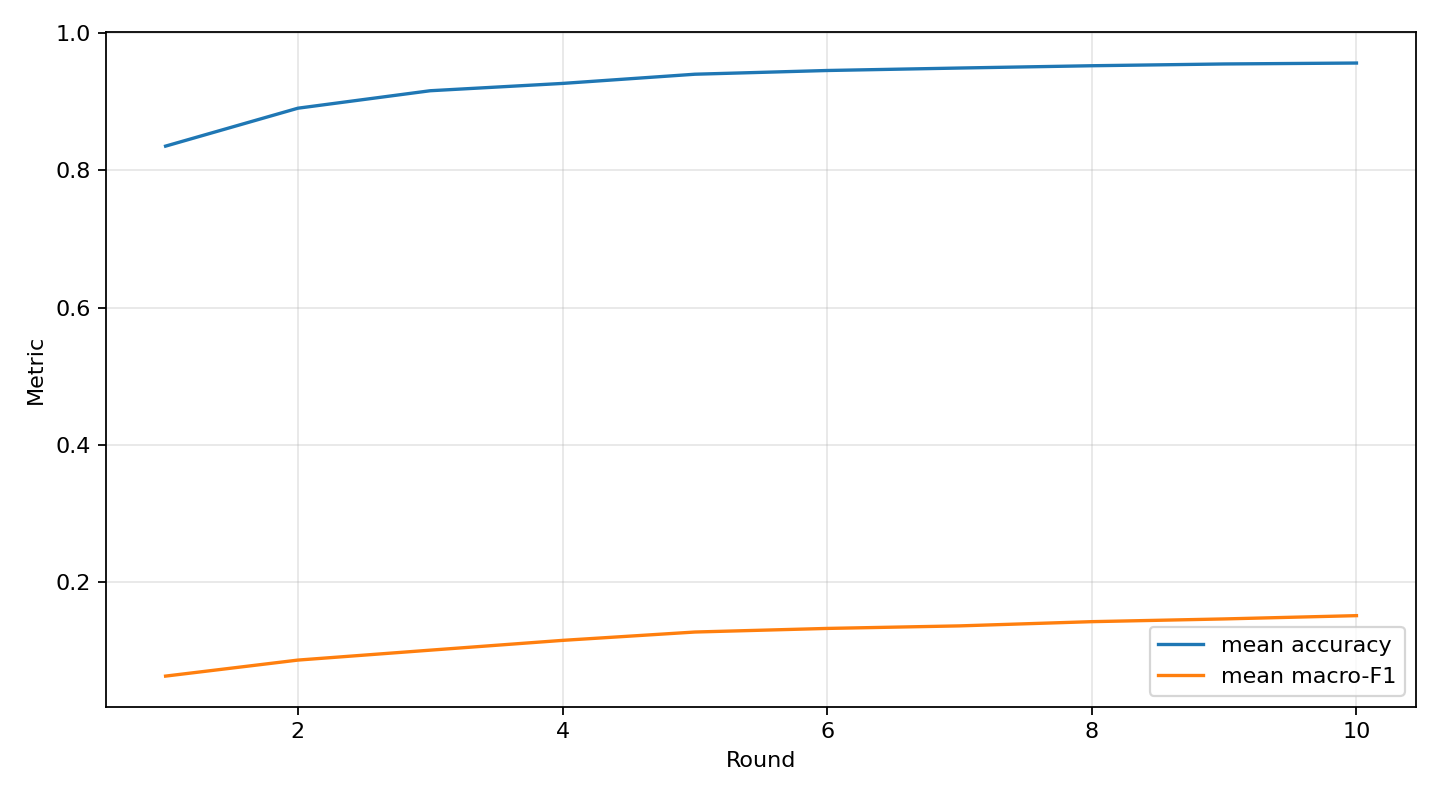

loss_curves.png


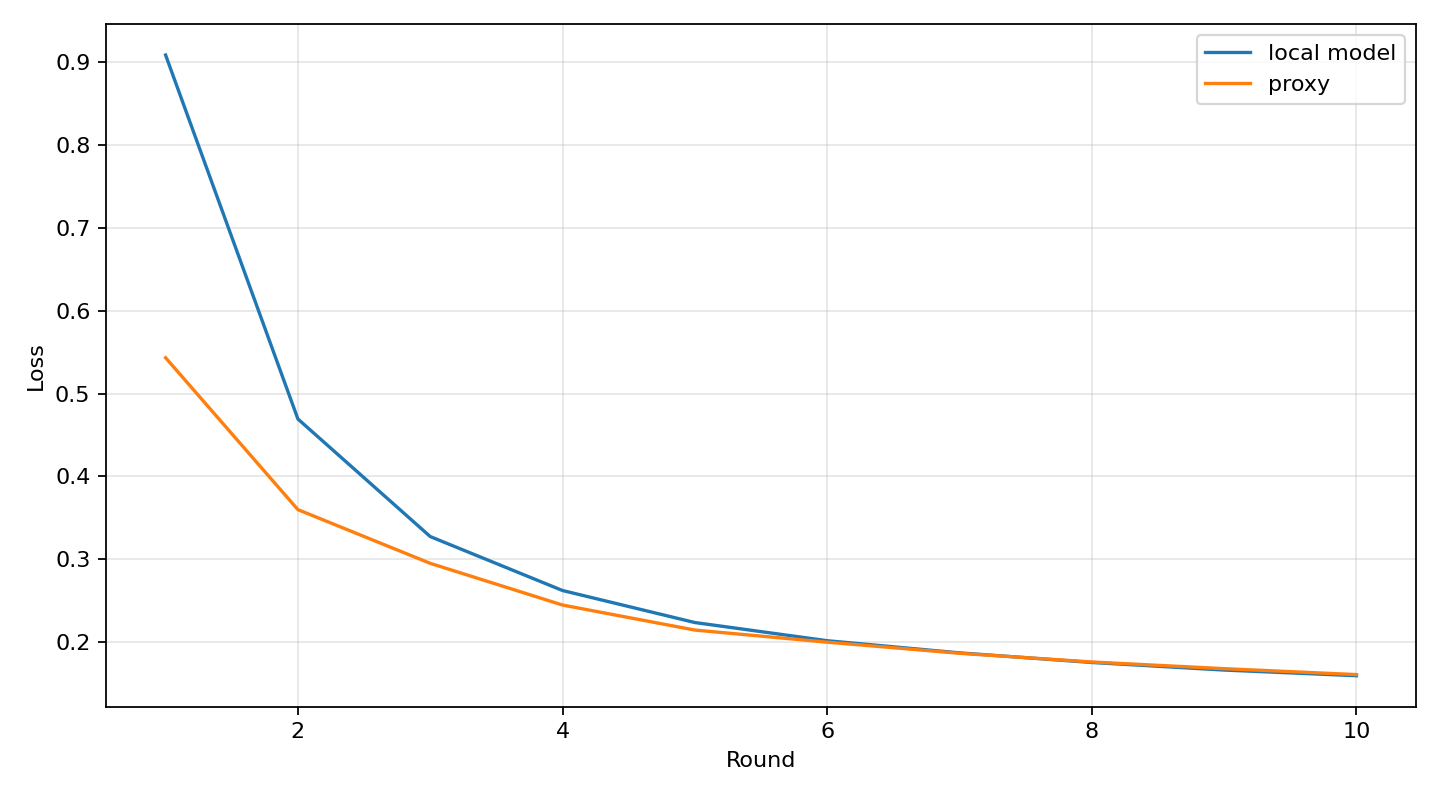

confusion_matrix.png


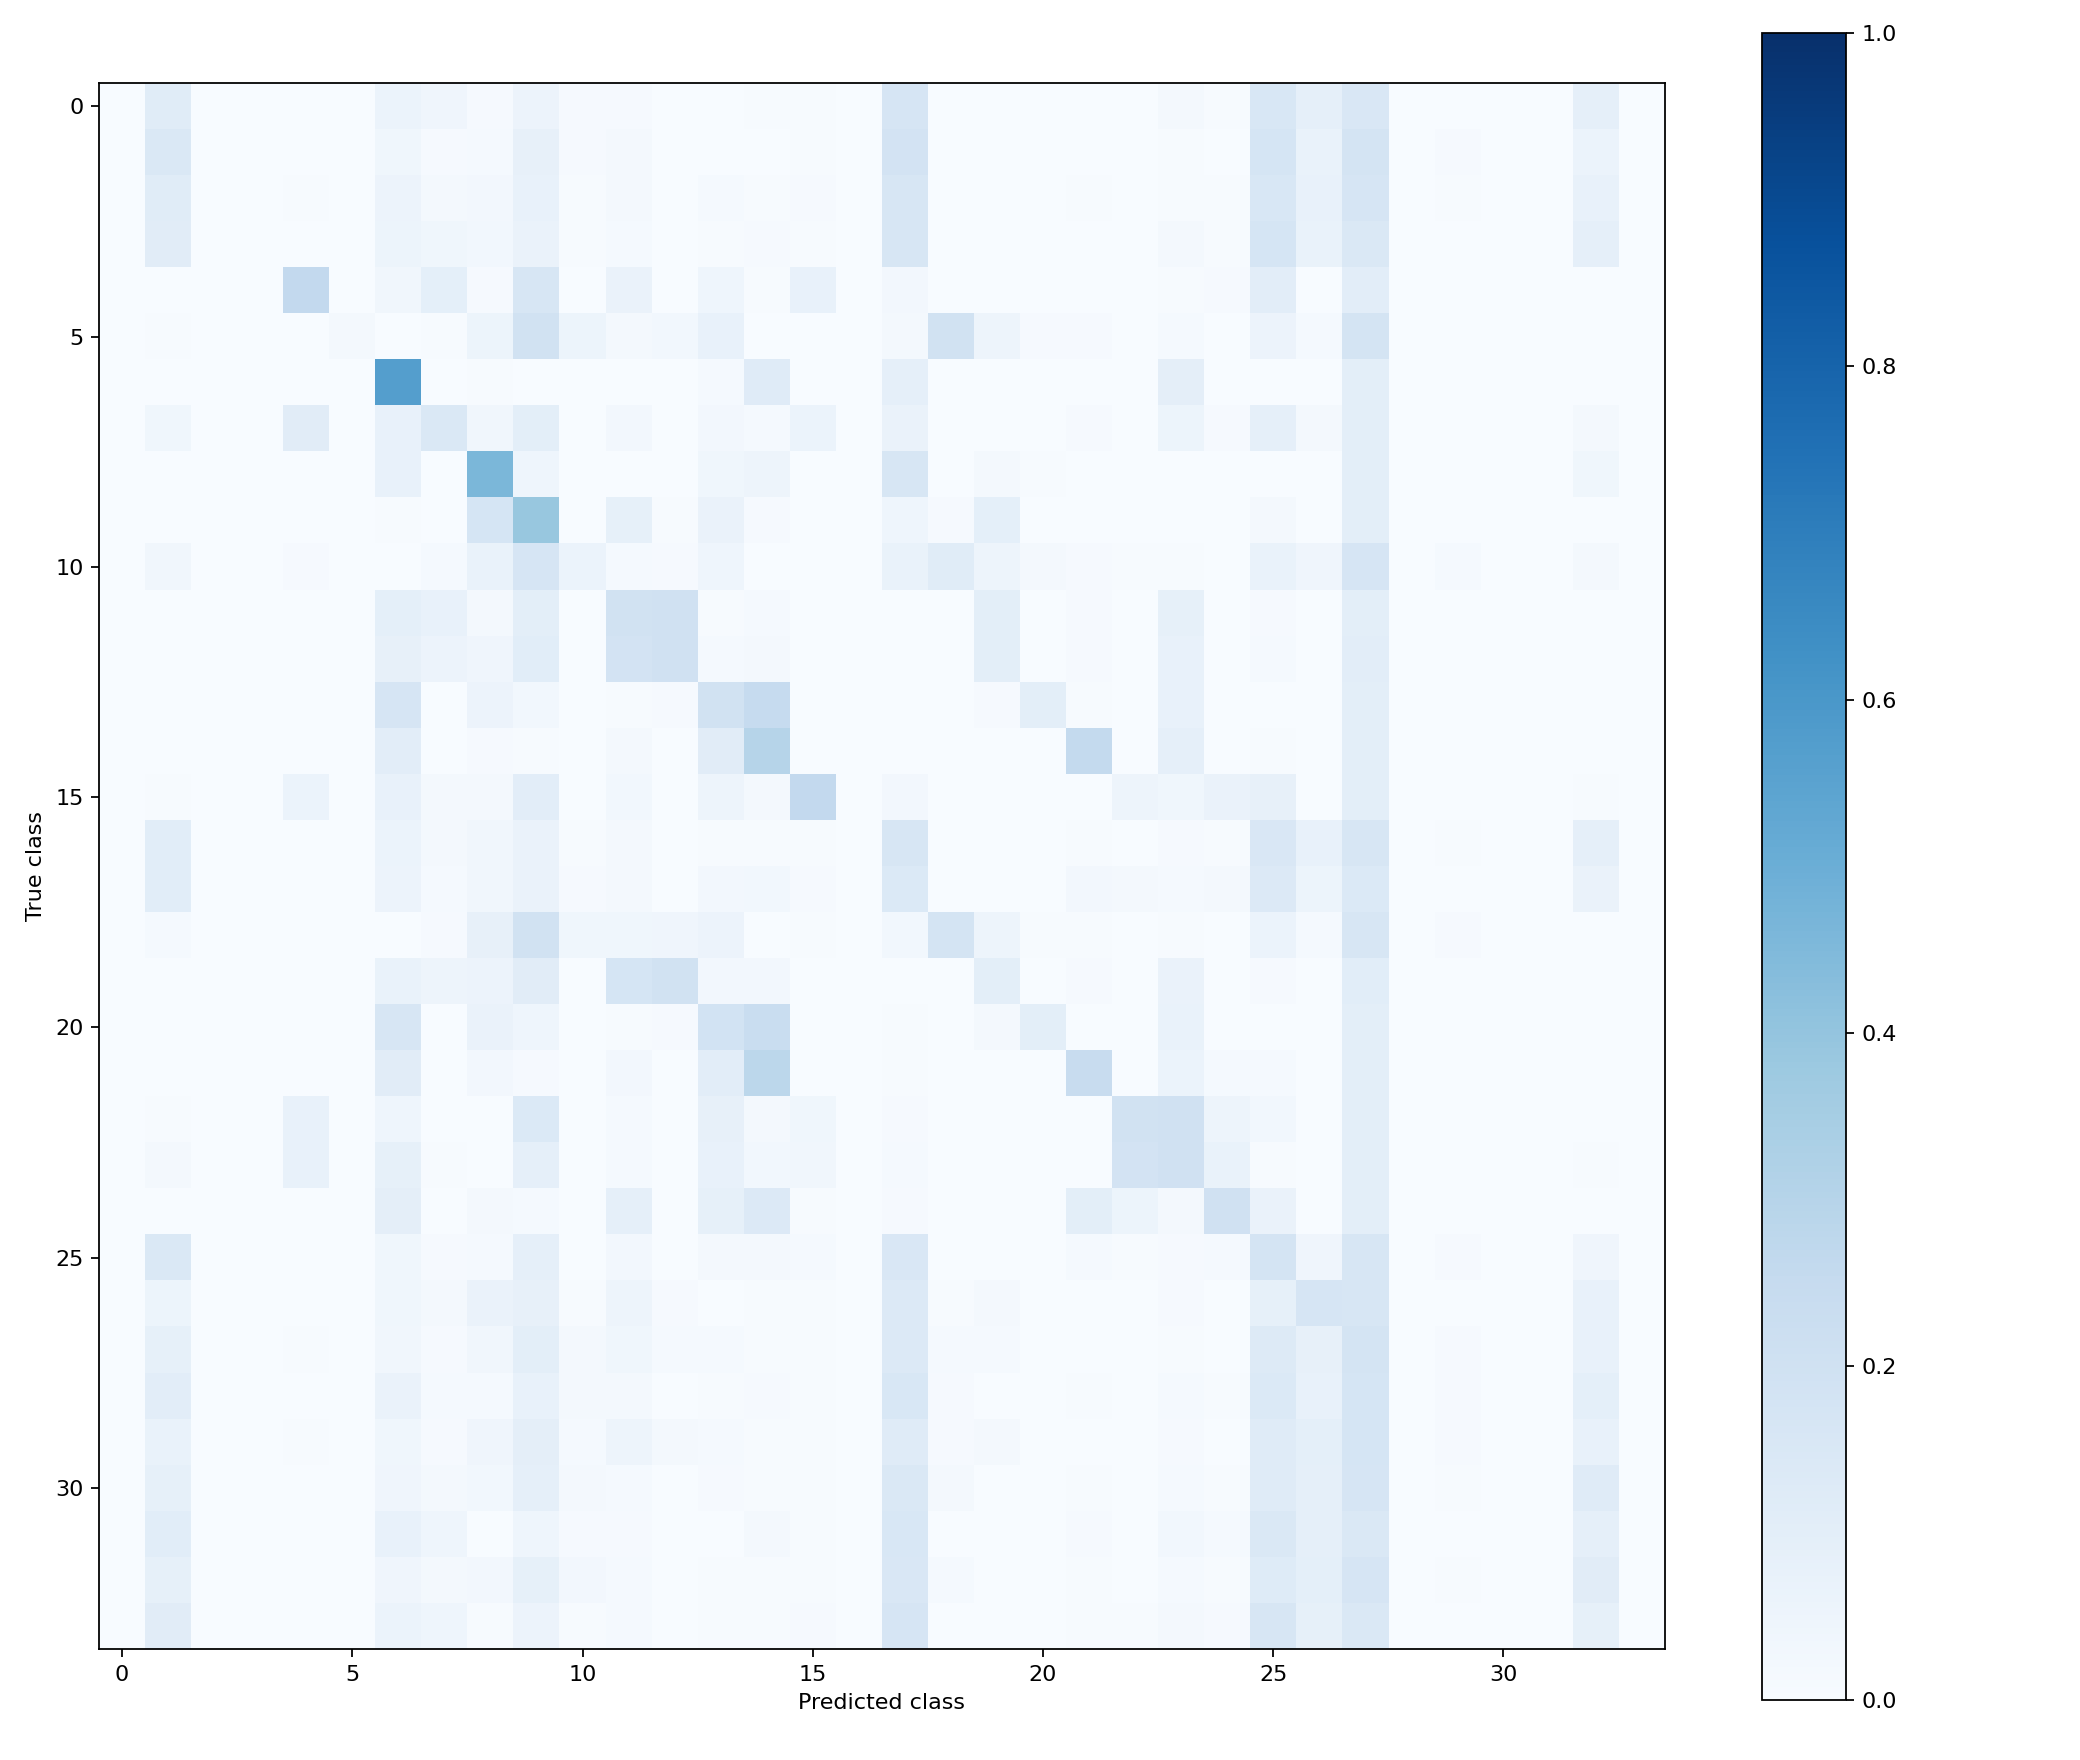

per_class_f1.png


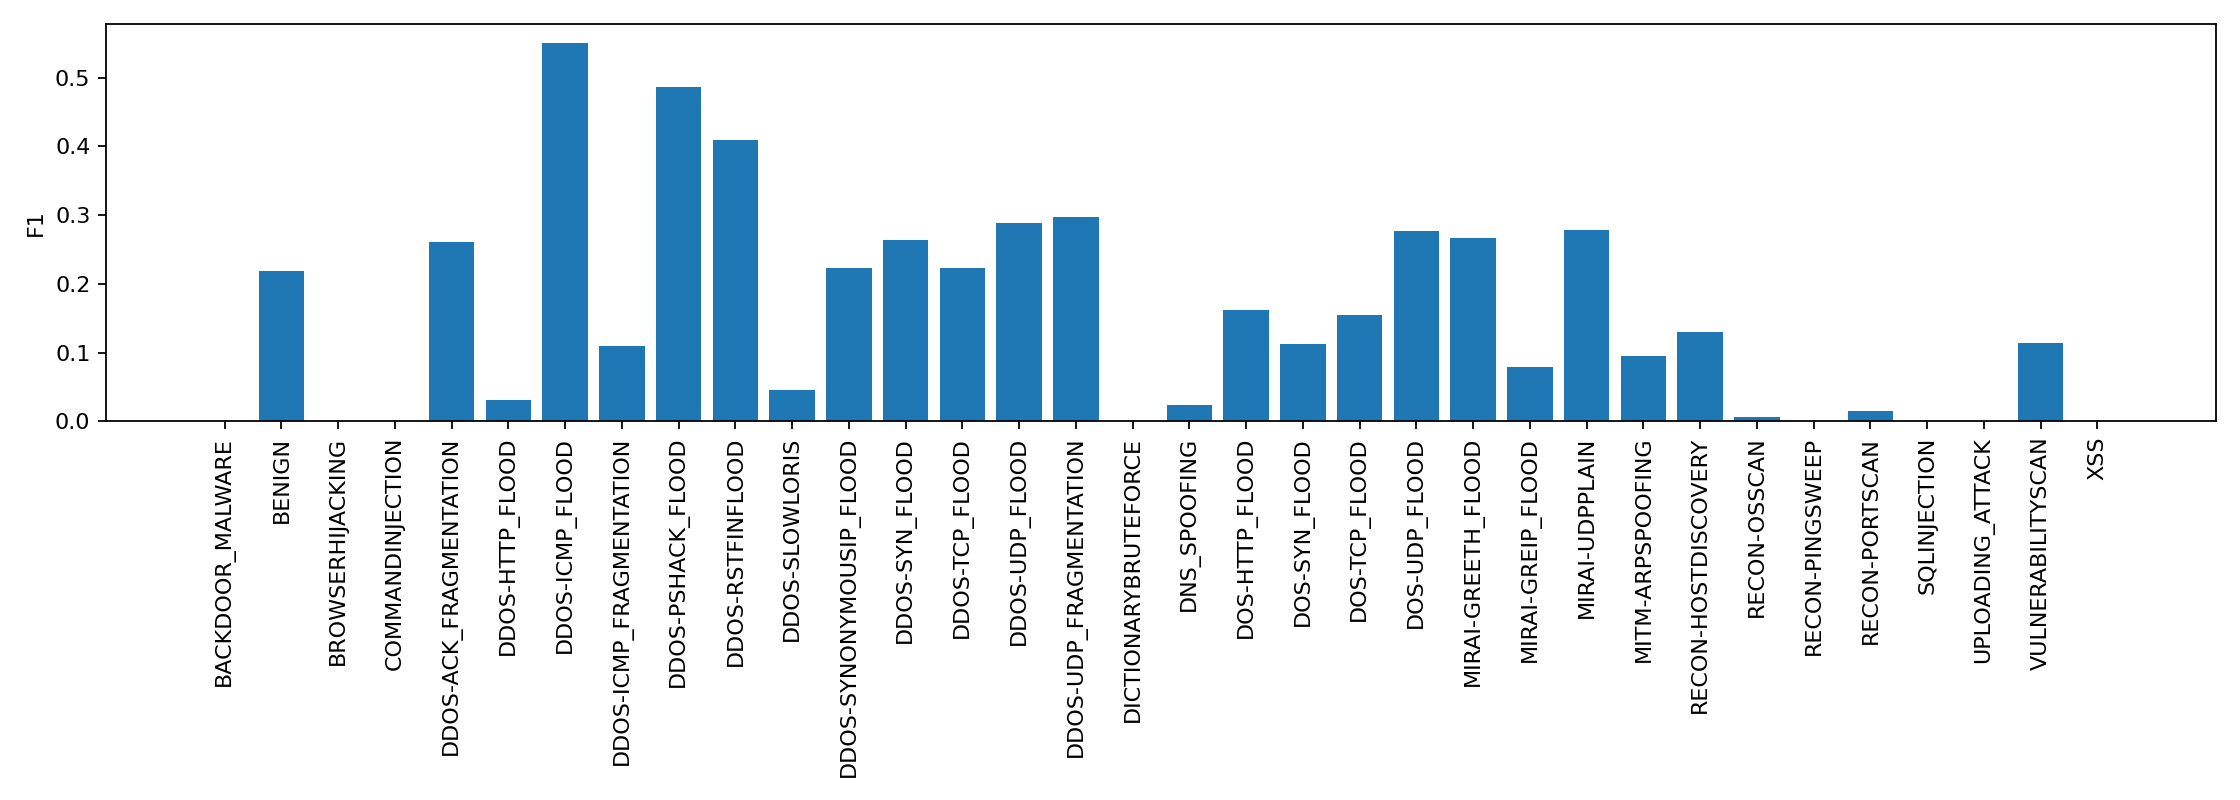

runtime_per_round.png


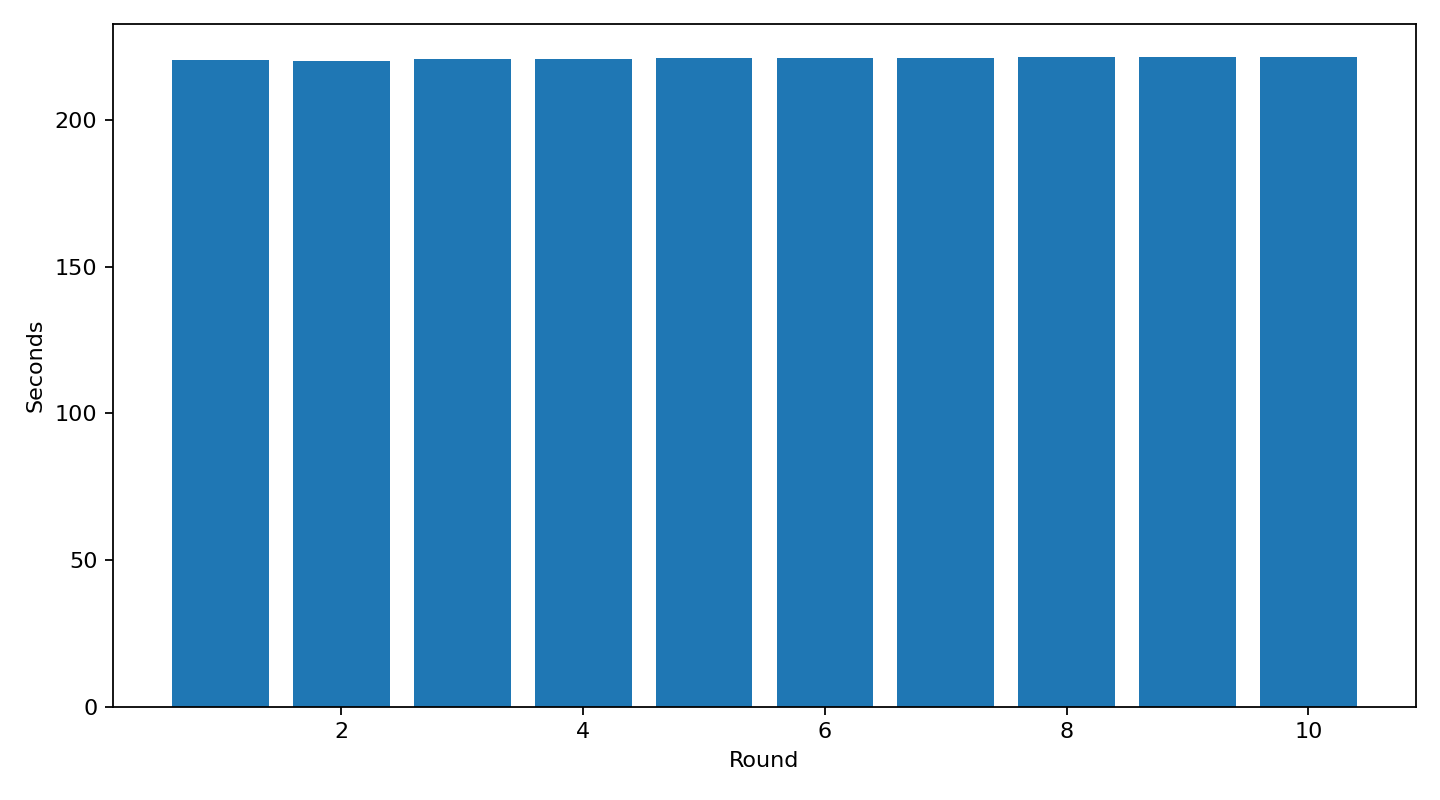

communication_cumulative.png


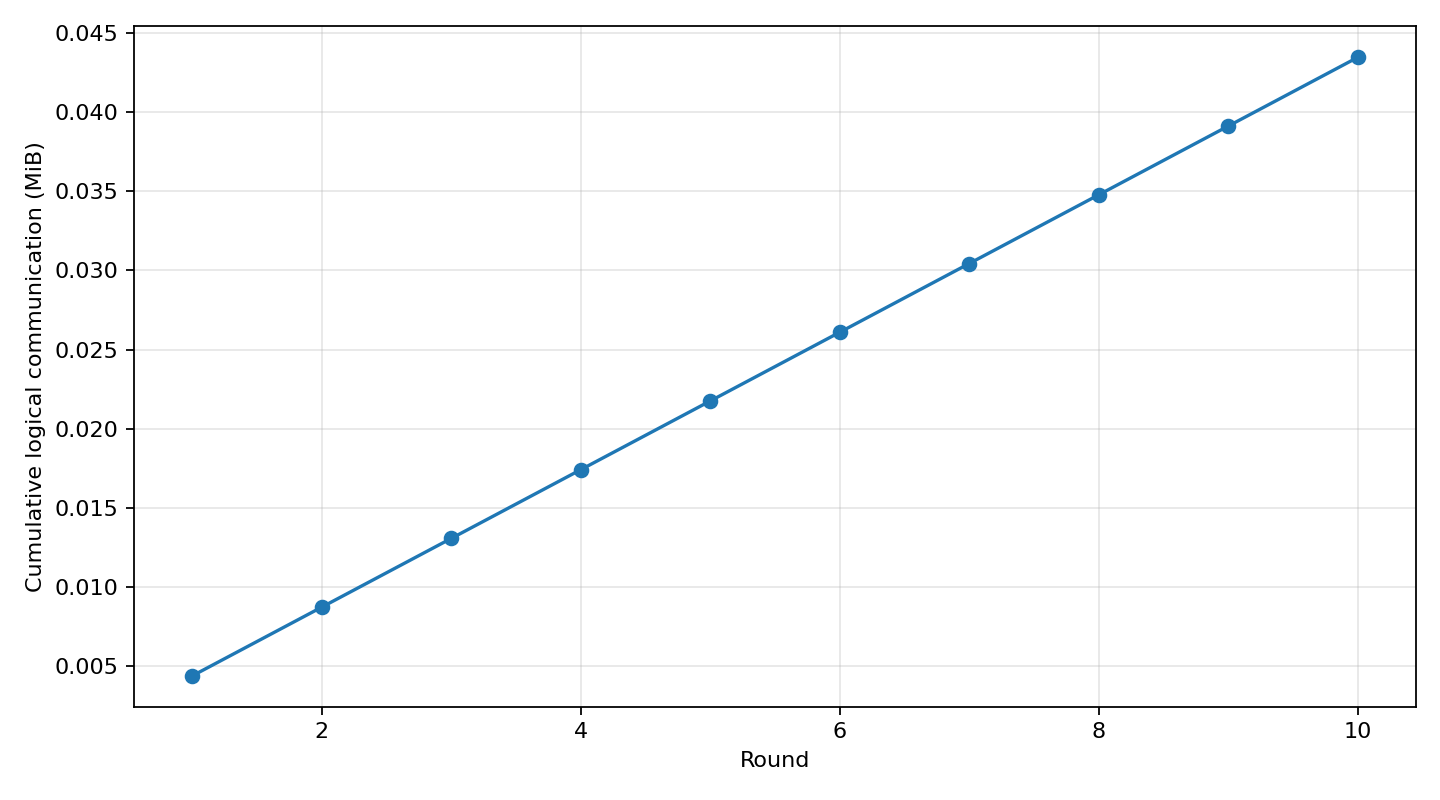

In [8]:
from IPython.display import Image, display

for plot_name in [
    "accuracy_f1_curves.png",
    "loss_curves.png",
    "confusion_matrix.png",
    "per_class_f1.png",
    "runtime_per_round.png",
    "communication_cumulative.png",
]:
    print(plot_name)
    display(Image(filename=str(OUTPUT_DIR / "artifacts" / plot_name)))
